In [1]:
import pickle
import numpy as np
import os
import tqdm
import torch
import gc

from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()

from importlib import reload
from matplotlib import pyplot as plt

import matrix_approx_zeshel

matrix_approx_zeshel = reload(matrix_approx_zeshel)

!ls  | grep matrix_approx_zeshel

2023-11-06 22:10:11.353869: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-11-06 22:10:11.426265: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-11-06 22:10:11.427612: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-11-06 22:10:12.508273: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


matrix_approx_zeshel.py


# Open Data loader & context

In [2]:
def load_ment_to_ent_scores(directory = "yugioh", shuffle_rows = 0, full = True):
    data = list()

    for file in os.listdir(directory):
        path = f"{directory}/{file}"
        print(f"Loading file {path}")
        with open(path, "rb") as f:
            data.append(
                pickle.load(f)
            )
    data = sorted(data, key = lambda x: x["arg_dict"]["n_ment_start"])

    for i in range(len(data) - 1):
        if full:
            assert data[i]["arg_dict"]["n_ment_start"] + data[i]["arg_dict"]["n_ment"] == data[i + 1]["arg_dict"]["n_ment_start"]
        else:
            assert data[i]["arg_dict"]["n_ment_start"] + data[i]["arg_dict"]["n_ment"] <= data[i + 1]["arg_dict"]["n_ment_start"]
        
    ment_to_ent_scores = list(map(lambda x: x["ment_to_ent_scores"], data))
    ment_to_ent_scores = np.vstack(ment_to_ent_scores)
    print("Loaded shape = ", ment_to_ent_scores.shape)
    
    if shuffle_rows:
        print(f"Shuffling... (seed = {shuffle_rows})")
        np.random.seed(shuffle_rows)
        np.random.shuffle(ment_to_ent_scores)
    
    return ment_to_ent_scores

In [3]:
from sklearn.cluster import KMeans

def from_labels(X, labels):
    K = list()
    for i in range(100):
        sl_i = np.arange(X.shape[0])[labels == i]
        sl = X[labels == i]
        
        if len(sl_i) == 0:
            # bug-mode
            while True:
                chosen = np.random.choice(np.arange(X.shape[0])[labels < i], size=1)[0]
                if chosen not in K:
                    K.append(chosen)
                    break
            continue
            
        center = sl.mean(axis=0).reshape(1, -1)
        best = euclidean_distances(sl, center).argmin()
        K.append(sl_i[best])
        assert labels[K[-1]] == i
    return K

class EvalContextRelevs:
    def __init__(self, relevs, key_size = 100, train_size = 0.7, key_games = None, seed = 17, det_attempts = 0):
        self.relevs = np.array(relevs)
        self.reqs_count = self.relevs.shape[0]
        self.games_count = self.relevs.shape[1]
        
        self.key_size = key_size
        self.key_games = (
            np.random.choice(np.arange(self.games_count), key_size, replace=False)
            if key_games is None else
            key_games
        )
        np.random.seed(seed)
        #np.random.shuffle(self.requests)

        self.try_det_attempts(det_attempts)
        self.train_split = int(self.reqs_count * train_size)

        assert key_size + 1 < self.train_split


        self.key_relevs = self.relevs[:key_size]
        self.train_relevs = self.relevs[key_size + 1: self.train_split]
        self.test_relevs = self.relevs[self.train_split:]

        self.slices = ["key", "train", "test"]
        print(len(self.key_relevs), len(self.train_relevs), len(self.test_relevs))

    def get_top_games(self):
        return self.relevs.mean(axis=0).argsort()[:100]

    def set_top_games_as_key(self):
        self.key_games = self.get_top_games()
        return self

    def get_kmeans_games(self, all_from_labels=True):
        X = self.get_relevs("train").T

        k_func = (
            (lambda C : euclidean_distances(X, C.cluster_centers_).argmin(axis=0))
            if not all_from_labels else
            (lambda C : from_labels(X, C.labels_))
        )
        K_KMeans = k_func(
            KMeans(n_clusters=self.key_size, random_state=0).fit(X)  #, n_init="auto").fit(X)
        )
        
        return K_KMeans
    
    def set_kmeans_games_as_key(self, *args, **kwargs):
        self.key_games = self.get_kmeans_games(*args, **kwargs)
        return self
    

    def try_det_attempts(self, det_attempts):
        def get_det(r):
            kr = r[:self.key_size, self.key_games] - r.mean()
            return np.abs(np.linalg.det(kr))

        best_i_array = np.arange(len(self.relevs))

        for i in range(det_attempts):

            r_i_array = np.arange(len(self.relevs))
            np.random.shuffle(r_i_array)

            n, o = get_det(self.relevs[r_i_array, :]), get_det(self.relevs[best_i_array, :])
            
            # print(f"try update key_reqs ({o} vs {n}...")
            if n > o:
                best_i_array = r_i_array
                print(f"updated det ({i}, {o} -> {n})")

        print("Best det = ", get_det(self.relevs[best_i_array, :]))

        self.relevs = self.relevs[best_i_array, :]
        print("Current de = ", get_det(self.relevs))
        
    def get_relevs(self, t = "train"):
        if t == "train":
            return self.train_relevs
        elif t == "key":
            return self.key_relevs
        elif t == "test":
            return self.test_relevs
        else:
            assert False
            
    def get_requests(self, t = "train"):
        if t == "train":
            return self.train_reqs
        elif t == "key":
            return self.key_reqs
        elif t == "test":
            return self.test_reqs
        else:
            assert False

# Games Data loader & context

In [4]:
import collections
import pickle
import numpy as np
import tqdm
import os
import gc

import matplotlib.pyplot as plt


def load(limit, raw_path = "stand/log.local.logtime2.txt", path = "log.local.logtime2.bin", key_games = None, seed = 17, det_attempts = 0):
    readvector = lambda s : np.array(list(map(float, s.strip()[1:-2].split(","))))
    requests = list()
    docembs = collections.defaultdict(dict)

    if os.path.isfile(path):
        with open(path, "rb") as f:
            flimit, frequests, fdocembs = pickle.load(f)
            if flimit == limit:
                requests, docembs = frequests, fdocembs
            else:
                print(f"WARN: buffered limit is different, {flimit} != {limit}, reloading...")

    if not requests:
        with open(raw_path) as f:
            req = list()
            reqid = None
            models = list()
            prevreqmodel = None
            reqmodel = dict()
            prevmodelid = -1
            bannermodelid = -1
            for i, line in tqdm.tqdm_notebook(enumerate(f)):
                if line.startswith("Model = 6;"):
                    prevreqmodel = reqmodel
                    reqmodel = dict()

                if line.startswith("Model = "):
                    spl = line.split(" ")
                    prevmodelid = int(spl[2][:-1])
                    bannermodelid = max(bannermodelid , prevmodelid)
                    reqmodel[prevmodelid] = readvector(spl[3])
                elif line.startswith("dbid"):
                    spl = line.split(" ")
                    dbid = int(spl[1][:-1])
                    docembs[bannermodelid][dbid] = readvector(spl[2])
                elif line.startswith("seed"):
                    if len(requests) >= limit:
                        break
                    if req:
                        requests.append((reqid, prevreqmodel, sorted(req)))
                        req = list()
                    reqid = "$_" + (line.split()[1] + "_" + line.split()[3])
                else:
                    req.append(
                        (int(line.split()[0]), float(line.split()[1]))
                    )
        
        with open(path, "wb") as f:
            pickle.dump((limit, requests, docembs), f)

    games_count = len(requests[0][2])
    assert games_count == 16514
    requests = [r for r in requests if len(r[2]) == games_count]
    
    print([(i, len(docembs[i].keys())) for i in docembs])  # should be equal
    docblocks = {
        mid : np.array([x[1] for x in sorted(list(docembs[mid].items()))])
        for mid in docembs
    }
    
    class EvalContext:
        def __init__(self, games_count = games_count, key_size = 100, train_size = 0.7, key_games = None, seed = 17, det_attempts = 0):
            self.games_count = games_count
            
            self.key_size = key_size
            self.key_games = (
                np.random.choice(np.arange(games_count), key_size, replace=False)
                if key_games is None else
                key_games
            )

            self.requests = requests
            np.random.seed(seed)
            np.random.shuffle(self.requests)
            
            self.try_det_attempts(det_attempts)

            self.key_reqs = self.requests[:key_size + 1]
            self.key_reqs_idx = np.arange(key_size + 1)

            self.train_split = int(len(self.requests) * train_size)

            assert key_size + 1 < self.train_split

            self.train_reqs = self.requests[key_size + 1: self.train_split]
            self.test_reqs = self.requests[self.train_split:]

            self.slices = ["key", "train", "test"]
            print(len(self.key_reqs), len(self.train_reqs), len(self.test_reqs))

            self.docblocks = docblocks
            self.relevs = dict()
            
        def get_top_games(self):
            if not hasattr(self, "top_games"):
                embed_games = np.array([
                    np.array([r[2][g_i][1] for r in self.get_requests("train")])
                    for g_i in range(self.games_count)
                ])

                self.embed_games_mean = embed_games.mean(axis=1)
                self.top_games_all = (-self.embed_games_mean).argsort()
                self.top_games = self.top_games_all[:len(self.key_games)]

            return self.top_games
        
        def set_top_games_as_key(self):
            self.key_games = self.get_top_games()
            return self
        
        def get_kmeans_games(self, all_from_labels=True):
            X = self.get_relevs("train").T

            k_func = (
                (lambda C : euclidean_distances(X, C.cluster_centers_).argmin(axis=0))
                if not all_from_labels else
                (lambda C : from_labels(X, C.labels_))
            )
            K_KMeans = k_func(
                KMeans(n_clusters=self.key_size, random_state=0).fit(X)  #, n_init="auto").fit(X)
            )

            return K_KMeans

        def set_kmeans_games_as_key(self, *args, **kwargs):
            self.key_games = self.get_kmeans_games(*args, **kwargs)
            return self

        def try_det_attempts(self, det_attempts, model_id = 6):
            def get_det(r, r_i_array):
                kr = np.array([
                    r[r_i][1][model_id]
                    for r_i in r_i_array[:100]
                ])
                return np.abs(np.linalg.det(kr[:kr.shape[1], :]))

            best_i_array = np.arange(len(self.requests))

            for _ in range(det_attempts):
                # print("try update key_reqs...")
                
                r_i_array = np.arange(len(self.requests))
                np.random.shuffle(r_i_array)
                
                n, o = get_det(self.requests, r_i_array), get_det(self.requests, best_i_array)
                # print(n, o)
                if n > o:
                    best_i_array = r_i_array
                    # print("updated!")

            print("Best det = ", get_det(self.requests, best_i_array))
            
            new_requests = [
                self.requests[i]
                for i in best_i_array
            ]
            
            del self.requests
            gc.collect()

            self.requests = new_requests
            print(get_det(self.requests, np.arange(len(self.requests))))

        def get_relevs(self, t = "train"):
            if t not in self.relevs:
                self.relevs[t] = np.array([
                    np.array([g_i[1] for g_i in r[2]])
                    for r in self.get_requests(t)
                ])
                
            return self.relevs[t]

        def get_requests(self, t = "train"):
            if t == "train":
                return self.train_reqs
            elif t == "key":
                return self.key_reqs
            elif t == "test":
                return self.test_reqs
            else:
                assert False

    return EvalContext(key_games = key_games, seed = seed, det_attempts = det_attempts)

# Models

In [5]:
class Popular:
    def __init__(self, ctx):
        self.ctx = ctx
        self.game_avg_scores = {
            t : self.get_user_scores(t).mean(axis = 0)
            for t in self.ctx.slices
        }
        self.trus_top = dict()
        
    def get_user_scores(self, t):
        return self.ctx.get_relevs(t)
    
    def get_user_embs(self, t):
        assert False
    
    def get_game_embs(self):
        assert False

    def fit(self, t = "train"):
        self.top_logits = self.game_avg_scores[t]
        self.top = np.argsort(-self.top_logits)

    def recommend(self, t):
        return [self.top_logits for _ in self.get_user_scores(t)]
    
    def get_score(self, t, topsize = 100):    
        recs = self.recommend(t)
        
        if isinstance(recs, list):
            recs = np.array(recs)
        
        mse = np.mean((recs - self.get_user_scores(t)) ** 2)
        
        if isinstance(recs, tf.Tensor):
            recs = tf.argsort(-recs, axis=1)[:, :topsize].numpy()
        else:
            recs = np.argsort(-recs, axis=1)[:, :topsize]
        
        if (t, topsize) not in self.trus_top:
            trus = self.get_user_scores(t)
            trus = np.argsort(-trus, axis=1)[:, :topsize]
            self.trus_top[(t, topsize)] = trus
            
        trus = self.trus_top[(t, topsize)]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 
            
        results = [
            ev(rec, tru) / float(topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results) = ",
              np.mean(results), mse, len(results))

        return np.mean(results)

In [6]:
import tensorflow as tf
import copy
import tensorflow_ranking as tfr

DEFAULT_FIT_KWARGS = {
    "learning_rate": 0.001,
    "n": 500,
    "c": 5000,
    "matrix_l2": 0,
    "dssm_l2": 0,
    "train_popbias": False,
    "train_bias": False,
    "train_vbias": False,
    "verbose": True,
    "train_matrix": True,
    "train_dssm": False,
    "loss": "mse",
    "ubatch": 1e9,
    "activation": "relu",
    "score_verbose": 0,
    "trainable_items": False,
    "use_keys_in_train": False,
    "Winit": "glorot0.01",
    "Wfreeze": False,
    "TEinit": "legacy",
    "normalize_embs": True
}

class CBKnnV0(Popular):
    def __init__(self, ctx, fit_kwargs = dict()):
        super().__init__(ctx)
        
        p = copy.copy(DEFAULT_FIT_KWARGS)
        p.update(fit_kwargs)
        self.fit_kwargs = p
        
        p = copy.copy(DEFAULT_FIT_KWARGS)
        p.update(self.fit_kwargs)
        
        self.embed_users = {
            t : np.array([
                    np.array([r_i[i] for i in sorted(ctx.key_games)])
                    for r_i in ctx.get_relevs(t)
                ])
            for t in ctx.slices
        }
        self.embed_users_mean = {
            t : self.embed_users[t].mean(axis = 0)
            for t in ctx.slices
        }
        # embed_users = embed_users - embed_users_mean
        print("self.embed_users['train'].shape = ", self.embed_users['train'].shape )
        
        self.embed_games = np.array([
            np.array([r[g_i] for r in ctx.get_relevs("key")])
            for g_i in range(ctx.games_count)
        ])
        
        self.embed_games_mean = self.embed_games.mean(axis = 0)
        
        # embed_games = embed_games - embed_games_mean
        print("self.embed_games.shape = ", self.embed_games.shape)
        
        
        if self.fit_kwargs["trainable_items"]:
            if self.fit_kwargs["TEinit"] == "legacy":
                value = self.embed_games
            elif self.fit_kwargs["TEinit"] == "anncur":
                key_cols_idx = np.array(sorted(ctx.key_games))
                value = (
                    np.linalg.pinv(ctx.get_relevs("train")[:, key_cols_idx])
                    @ ctx.get_relevs("train")
                ).T
                print(type(value))
            else:
                assert False, "unknown TEinit: " + str(self.fit_kwargs["TEinit"])
                
            self.trainable_games = tf.Variable(
                tf.convert_to_tensor(value, dtype=tf.float32),
                trainable=True
            )
        else:
            if self.fit_kwargs["TEinit"] == "anncur":
                key_cols_idx = np.array(sorted(ctx.key_games))
                self.embed_games = (
                    np.linalg.pinv(ctx.get_relevs("train")[:, key_cols_idx])
                    @ ctx.get_relevs("train")
                ).T
                print("ANNCur init")
            
        
        self.games_top_key = self.embed_games.mean(axis = 1)
        
        self.games2users = np.array([
            self.embed_games[g_i]
            for g_i in ctx.key_games
        ])
        print("self.games2users.shape = ", self.games2users.shape)
        
        self.core_users_scores = ctx.get_relevs("key")
        print("self.core_users_scores.shape = ", self.core_users_scores.shape)
        
        self.core_users_embs = self.embed_users["key"]
        print("self.core_users_embs.shape = ", self.core_users_embs.shape)
        
        self.ge_users = (
            (self.embed_users["train"].T / self.embed_users["train"].mean(axis=1)).T @ self.games2users
        )
        # ge_users = embed_users @ games2users
        print("self.ge_users.shape = ", self.ge_users.shape)
    
    def __repr__(self):
        return "CbKnn(" + str(self.fit_kwargs) + ")"
        
    # inherited   
    # def get_user_scores(self, t):
    
    def get_user_embs(self, t):
        if self.fit_kwargs["normalize_embs"]:
            return (self.embed_users[t] - self.embed_users_mean["train"]) / self.embed_users[t].std(axis=0)
        else:
            return self.embed_users[t]
    
    def get_game_embs(self):
        if not self.fit_kwargs["trainable_items"]:
            if self.fit_kwargs["normalize_embs"]:
                return (self.embed_games - self.embed_games.mean(axis=0)) / self.embed_games.std(axis=0)
            else:
                return self.embed_games 
        else:
            return self.trainable_games

    def fit(self, **kwargs):
        p = copy.copy(DEFAULT_FIT_KWARGS)
        p.update(self.fit_kwargs)
        p.update(kwargs)

        self.p = p
        self.train_bias = p["train_bias"]
        self.train_vbias = p["train_vbias"]
        self.train_popbias = p["train_popbias"]
        self.train_matrix = p["train_matrix"]
        self.train_dssm = p["train_dssm"]
        self.loss = p["loss"]

        if p["use_keys_in_train"]:
            train_user_scores = np.vstack([
                self.get_user_scores("key"),
                self.get_user_scores("train")
            ])
            train_user_embs = np.vstack([
                self.get_user_embs("key"),
                self.get_user_embs("train")
            ])
        else:
            train_user_scores = self.get_user_scores("train")
            train_user_embs = self.get_user_embs("train")

        game_embs = self.get_game_embs()
        
        
        
        if self.p["Winit"] == "glorot0.01":
            initializer = tf.keras.initializers.GlorotUniform()
            values = initializer(shape=(train_user_embs.shape[1], game_embs.shape[1]))
            values = values / 100.  
        elif self.p["Winit"] == "glorot":
            initializer = tf.keras.initializers.GlorotUniform()
            values = initializer(shape=(train_user_embs.shape[1], game_embs.shape[1]))
        elif self.p["Winit"] == "eye":
            values = np.eye(train_user_embs.shape[1], game_embs.shape[1])
        else:
            assert False, "init is not known:" + str(self.p["init"])
            
        self.W = tf.Variable(values, trainable = True) 
        self.pb = tf.Variable(1., trainable = True) 
        self.b = tf.Variable(0., trainable = True) 
        
        if p["verbose"]:
            print("self.W = ", self.W)
            print("0-loss = ", tf.reduce_mean((train_user_scores - 0) ** 2))
    
        opt =  tf.keras.optimizers.Adam(learning_rate=p["learning_rate"])

        if self.train_dssm:
            self.train_dssm = True

            dim = game_embs.shape[1]
            self.g_dssm = tf.keras.Sequential([
                tf.keras.layers.Dense(dim, activation=p["activation"]),
                tf.keras.layers.Dense(dim, activation=None)
            ])
            self.g_dssm(game_embs)
            
            # dim = train_user_embs.shape[1]
            self.u_dssm = tf.keras.Sequential([
                tf.keras.layers.Dense(dim, activation=p["activation"]),
                tf.keras.layers.Dense(dim, activation=None)
            ])
            self.u_dssm(train_user_embs)
            
        if self.train_vbias:
            self.vb = tf.Variable(
                np.zeros_like(self.game_avg_scores["train"], dtype=np.float32),
                trainable = True
            ) 
        
        
        for i in range(p["n"]):
            def loss():
                def get_logits_scores(loss_batch = 1e9):
                    game_slice = None
                    
                    ubatch = p["ubatch"]
                    if ubatch >= train_user_scores.shape[0]:
                        train_user_embs_ = train_user_embs
                        scores_ = train_user_scores
                    else:
                        u_slice = np.random.choice(np.arange(train_user_scores.shape[0]), ubatch, replace = True)
                        train_user_embs_ = train_user_embs[u_slice]
                        scores_ = train_user_scores[u_slice]
                    
                    if loss_batch >= game_embs.shape[0]:
                        game_embs_ = game_embs
                        scores_ = scores_
                    else:
                        game_slice = np.random.choice(np.arange(game_embs.shape[0]), loss_batch, replace = True)
                        game_embs_ = (
                            game_embs[game_slice]
                            if isinstance(game_embs, np.ndarray) else
                            tf.gather(game_embs, game_slice)
                        )
                        scores_ = scores_[:, game_slice]
                        
                    
                    logits = 0
                    
                    if self.train_matrix:
                        logits += train_user_embs_ @ self.W @ tf.transpose(game_embs_)

                    if self.train_dssm:
                        logits += self.u_dssm(train_user_embs_) @ tf.transpose(self.g_dssm(game_embs_))
                    
                    if self.train_popbias:
                        if loss_batch >= game_embs.shape[0]:
                            logits += self.pb * self.game_avg_scores["train"]
                        else:
                            logits += self.pb * self.game_avg_scores["train"][game_slice]
                        
                    if self.train_vbias:
                        if loss_batch >= game_embs.shape[0]:
                            logits += self.vb
                        else:
                            logits += tf.gather(self.vb, game_slice)
                        
                    if self.train_bias:
                        logits += self.b
                        
                    return logits, scores_
                        
                if self.loss == "mse":
                    logits, scores = get_logits_scores(
                        loss_batch = (1e9 if "loss_batch" not in p else p["loss_batch"]))
                    v = tf.reduce_mean((scores - logits) ** 2)
                elif self.loss == "qmse":
                    logits, scores = get_logits_scores(
                        loss_batch = (1e9 if "loss_batch" not in p else p["loss_batch"]))
                    q_mean = scores.mean(axis=1)
                    v = tf.reduce_mean(((scores.T - q_mean).T - logits) ** 2)
                elif self.loss == "ApproxNDCGLoss":
                    while True:
                        logits, scores = get_logits_scores(
                            loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))

                        v = tfr.keras.losses.ApproxNDCGLoss()(
                            scores.astype(np.float32),
                            logits
                        )
                    
                        if not tf.math.is_nan(v).numpy().any():
                            break
                        else:
                            if p["verbose"]:
                                print("nanloss ignored")
                elif self.loss == "softmax":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        tf.nn.softmax(logits, axis=1),
                        0
                    ))
                elif self.loss == "softmax_signed":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    sf = tf.nn.softmax(logits, axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        sf,
                        -sf
                    ))
                elif self.loss == "softmax_weighted":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        tf.nn.softmax(logits, axis=1),
                        0
                    ) * scores)
                elif self.loss == "sigmoid_top_100":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    mask = np.argsort(-scores, axis=1) < 100
                    v = -tf.reduce_sum(
                        tf.math.log_sigmoid((2 * mask - 1) * logits)
                    )
                elif self.loss == "KL100":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    mask = np.argsort(-scores, axis=1) < 100
                    v = tf.keras.losses.KLDivergence()((scores.T >= qs.T).T, logits)
                else:
                    assert False
                    
                if self.p["c"]:
                    v += tf.reduce_mean(self.W * self.W) * p["c"]
                    
                if self.p["dssm_l2"]:
                    for weights_ in [self.u_dssm.weights, self.g_dssm.weights]:
                        for weight_ in weights_:
                            v += tf.reduce_sum(weight_ * weight_) * self.p["dssm_l2"]
                
                if self.p["matrix_l2"]:
                    v += tf.reduce_sum(self.W * self.W) * self.p["matrix_l2"]
                
                if p["verbose"]:
                    print(v.numpy())
                
                return v

            weights = list()
            
            if self.train_matrix and (not self.p["Wfreeze"]):
                weights += [self.W]

            if self.train_dssm:
                weights += self.u_dssm.weights
                weights += self.g_dssm.weights
            
            if self.train_popbias:
                weights += [self.pb]

            if self.train_vbias:
                weights += [self.vb]   
                
            if self.train_bias:
                weights += [self.b]   
                
            
            if self.p["trainable_items"]:
                weights += [self.trainable_games]
                
                
            opt.minimize(loss, weights)
            
            if p["score_verbose"] and (i % p["score_verbose"] == 0):
                print(f"\n=== Iteration {i} ===")
                for sl in self.ctx.slices:
                    print(f"slice = {sl}, score = {self.get_score(sl)}")
        print("last loss = ", loss())

    def recommend(self, t):
        logits = 0
                    
        if self.train_matrix:
            logits += self.get_user_embs(t) @ self.W @ tf.transpose(self.get_game_embs())

        if self.train_dssm:
            logits += self.u_dssm(self.get_user_embs(t)) @ tf.transpose(self.g_dssm(self.get_game_embs()))

        if self.train_popbias:
            logits += self.pb * self.game_avg_scores["train"]       
            
        if self.train_vbias:
            logits += self.vb
            
        if self.train_bias:
            logits += self.b
            
        return logits
    
    # inherited
    # def get_score(self, t, topsize = 100):
    
class DssmKnn(CBKnnV0):
    def __init__(self, ctx, modelid, fit_kwargs=dict()):
        super().__init__(ctx, fit_kwargs=fit_kwargs)
        self.modelid = modelid
        self.embed_games = ctx.docblocks[modelid]
        
    def __repr__(self):
        return "DssmKnn(" + str(self.modelid) + "," + str(self.fit_kwargs) + ")"
        
    def get_user_embs(self, t):
        return np.array([r[1][self.modelid] for r in self.ctx.get_requests(t)])
    
    def get_game_embs(self):
        return self.embed_games
    
def ev(mds, logs=None):
    for i in range(len(mds)):
        print("\n\n\n=======")
        print("model = ", mds[i])
        mds[i].fit()
        tr, te = mds[i].get_score("train"), mds[i].get_score("test")
        print(tr, te)
        if logs is not None:
            logs.append((
                repr(mds[i]),
                tr,
                te
            ))

In [7]:
class DssmKnn(CBKnnV0):
    def __init__(self, ctx, modelid, fit_kwargs=dict()):
        super().__init__(ctx, fit_kwargs=fit_kwargs)
        self.modelid = modelid
        self.embed_games = ctx.docblocks[modelid]
        
    def __repr__(self):
        return "DssmKnn(" + str(self.modelid) + "," + str(self.fit_kwargs) + ")"
        
    def get_user_embs(self, t):
        return np.array([r[1][self.modelid] for r in self.ctx.get_requests(t)])
    
    def get_game_embs(self):
        return self.embed_games
    
def ev(mds, logs=None):
    for i in range(len(mds)):
        print("\n\n\n=======")
        print("model = ", mds[i])
        mds[i].fit()
        tr, te = mds[i].get_score("train"), mds[i].get_score("test")
        print(tr, te)
        if logs is not None:
            logs.append((
                repr(mds[i]),
                tr,
                te
            ))

In [8]:
class AnnCUR(Popular):
    def __init__(self, ctx, oracle=False, key_games=None, name=None):
        super().__init__(ctx)
        self.oracle = oracle
        self.ctx = ctx
        self.name = name

        self.key_cols_idx = np.array(sorted(ctx.key_games if key_games is None else key_games))
        rows_idx = np.arange(ctx.get_relevs("train").shape[0])
        
        self.cur = matrix_approx_zeshel.CURApprox(
            rows=torch.from_numpy(ctx.get_relevs("train")),
            cols=torch.from_numpy(ctx.get_relevs("train")[:, self.key_cols_idx]),
            row_idxs=rows_idx,
            col_idxs=self.key_cols_idx,
            approx_preference="rows",
            A=(torch.from_numpy(ctx.get_relevs("train")) if oracle else None)
        )        
        
    def __repr__(self):
        if self.name is None:
            return f"AnnCur({id(self)})"
        else:
            return f"AnnCur({self.name} - {id(self)})"
        
    def get_user_scores(self, t):
        return self.ctx.get_relevs(t)
    
    def get_user_embs(self, t):
        assert False
    
    def get_game_embs(self):
        assert False

    def fit(self, t = "train"):
        self.top_logits = self.game_avg_scores[t]
        self.top = np.argsort(-self.top_logits)

    def recommend(self, t):
        key_relevs = torch.from_numpy(self.ctx.get_relevs(t)[:, self.key_cols_idx])
        return self.cur.get_complete_row(key_relevs)
    
    def get_score(self, t, topsize = 100):       
        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :topsize]
        trus = np.argsort(-trus, axis=1)[:, :topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 
            
        results = [
            ev(rec, tru) / float(topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results) = ",
              np.mean(results), mse, len(results))

        return np.mean(results)

# Evals

In [9]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances

def from_labels(X, labels):
    K = list()
    for i in range(100):
        sl_i = np.arange(X.shape[0])[labels == i]
        sl = X[labels == i]
        
        if len(sl_i) == 0:
            # bug-mode
            while True:
                chosen = np.random.choice(np.arange(X.shape[0])[labels < i], size=1)[0]
                if chosen not in K:
                    K.append(chosen)
                    break
            continue
            
        center = sl.mean(axis=0).reshape(1, -1)
        best = euclidean_distances(sl, center).argmin()
        K.append(sl_i[best])
        assert labels[K[-1]] == i
    return K

def K_by_min(X):
    center = X.mean(axis=0)
    K = [euclidean_distances(X, center.reshape(1, -1)).argmax()]

    while len(K) < 100:
        K.append(euclidean_distances(X, X[K]).min(axis=1).argmax())
    return K


def eval_clustering(ctx, all_from_labels=False):
    X = ctx.get_relevs("train").T
    from sklearn.cluster import KMeans
    
    k_func = (
        (lambda C : euclidean_distances(X, C.cluster_centers_).argmin(axis=0))
        if not all_from_labels else
        (lambda C : from_labels(X, C.labels_))
    )
    
    K_KMeans = k_func(
        KMeans(n_clusters=100, random_state=0).fit(X)  #, n_init="auto").fit(X)
    )


    from sklearn.cluster import BisectingKMeans
    K_BisectingKMeans = k_func(
        BisectingKMeans(n_clusters=100, random_state=0).fit(X)
    )


    from sklearn.cluster import MiniBatchKMeans
    K_MiniBatchKMeans = from_labels(
        X,
        MiniBatchKMeans(n_clusters=100, random_state=0).fit(X).labels_
    )

    from sklearn.cluster import AgglomerativeClustering
    K_AgglomerativeClustering = from_labels(
        X,
        AgglomerativeClustering(n_clusters=100).fit(X).labels_
    )

    from sklearn.cluster import SpectralCoclustering
    K_SpectralCoclustering = from_labels(
        X,
        SpectralCoclustering(n_clusters=100, random_state=0).fit(X).row_labels_
    )

    from sklearn.cluster import SpectralBiclustering
    K_SpectralBiclustering = from_labels(
        X,
        SpectralBiclustering(n_clusters=100, random_state=0).fit(X).row_labels_
    )

    from sklearn.cluster import SpectralClustering
    K_SpectralClusteringNN = from_labels(
        X,
        SpectralClustering(n_clusters=100, random_state=0, affinity="nearest_neighbors", n_jobs=-1).fit(X).labels_
    )

    K_ByMin = K_by_min(X)

    ev([
        Popular(ctx),
        AnnCUR(ctx),
        AnnCUR(ctx, key_games=np.arange(100), name="key_games=np.arange(100)"),
        AnnCUR(ctx, key_games=np.random.choice(np.arange(X.shape[0]), size=100, replace=False), name="random"),
        AnnCUR(ctx, key_games=K_KMeans, name="K_KMeans"),
        AnnCUR(ctx, key_games=K_BisectingKMeans, name="K_BisectingKMeans"),
        AnnCUR(ctx, key_games=K_MiniBatchKMeans, name="K_MiniBatchKMeans"),
        AnnCUR(ctx, key_games=K_AgglomerativeClustering, name="K_AgglomerativeClustering"),
        AnnCUR(ctx, key_games=K_SpectralCoclustering, name="K_SpectralCoclustering"),
        AnnCUR(ctx, key_games=K_SpectralBiclustering, name="K_SpectralBiclustering"),
        AnnCUR(ctx, key_games=K_SpectralClusteringNN, name="K_SpectralClusteringNN"),
        AnnCUR(ctx, key_games=K_ByMin, name="K_ByMin"),
    ])

In [10]:
DATASETS = ["yugioh", "pro_wrestling", "star_trek", "doctor_who", "military"]

# support items choice

In [11]:
# setup:
# 1000 items, 1000 + 1000 queries
recall_k = 5
n_runs = 10
n_items_per_run = 1000
test_item_cnt = 100
item_cnt_range = list(range(5, 101, 5))
assert test_item_cnt in item_cnt_range

In [12]:
from collections import defaultdict
from itertools import combinations

from matplotlib import pyplot as plt
import numpy as np
import os
from sklearn.metrics import top_k_accuracy_score
from sklearn.cluster import KMeans
from scipy.stats import mannwhitneyu, ttest_rel

In [13]:
#with open("collections_10000_items/test.npy", "rb") as fin:
#    all_test = np.load(fin)
#with open("collections_10000_items/train.npy", "rb") as fin:
#    all_train = np.load(fin)

#assert all_train.shape[0] == n_runs * n_items_per_run
#assert all_test.shape[0] == n_runs * n_items_per_run


In [14]:
def eval_items(items, train, test):
    item_embeds = train.dot(np.linalg.pinv(train[items]))
    approx_test_rel = item_embeds.dot(test[items])
    approx_train_rel = item_embeds.dot(train[items])
    best_items = np.argsort(test, axis=0)[-1]
    recall = top_k_accuracy_score(best_items, approx_test_rel.T, k=recall_k, labels=np.arange(train.shape[0]))
    test_mse = np.mean((test - approx_test_rel) ** 2)
    train_mse = np.mean((train - approx_train_rel) ** 2)
    return recall, test_mse, train_mse

def get_rnd_items(n_items, train):
    return np.random.choice(train.shape[0], n_items, replace=False)

def get_kmeans_items(n_items, train):
    kmeans = KMeans(n_clusters=n_items, n_init="auto").fit(train)
    items = []
    for center in kmeans.cluster_centers_:
        distances = ((train - center) ** 2).sum(axis=1)
        assert distances.shape == (train.shape[0],)
        for item_id in np.argsort(distances):
            if item_id not in items:
                items.append(item_id)
                break
    return np.array(items, dtype=np.int64)

greedy_items = []
def get_greedy(n_items, train, lazy=True):
    global greedy_items
    if not lazy:
        greedy_items = []
    if len(greedy_items) >= n_items:
        return np.array(greedy_items[:n_items], dtype=np.int64)
    
    gram = train.dot(train.T)
    gram /= gram.mean()
    items = []
    remaining_items = np.ones(train.shape[0], dtype="bool")
    for t in range(n_items):
        scores = (gram ** 2).sum(axis=1)
        assert np.allclose(scores[~remaining_items], np.zeros_like(scores[~remaining_items])), (
            t, scores[~remaining_items]
        )
        scores[remaining_items] /= gram[remaining_items, remaining_items]
        if max(scores) < 1e-9:
            break
        new_item = scores.argmax()
        assert remaining_items[new_item]
        coefs = gram[new_item] / np.sqrt(gram[new_item, new_item])
        diff = coefs.reshape(-1, 1).dot(coefs.reshape(1, -1))
        gram -= diff
        assert np.allclose(gram[new_item], np.zeros_like(gram[new_item]), atol=1e-6), (
            t, gram[new_item].std()
        )
        items.append(new_item)
        remaining_items[new_item] = False
    assert len(items) == n_items
    greedy_items.clear()
    greedy_items.extend(items)
    return np.array(items, dtype=np.int64)


### fast-a

In [15]:
def coitem_algorithm(n_support, candidate_items, target_items, min_item_rel_norm=1e-5, eps=1e-6):
    support_items = []
    support_items_scores = []
    n_c, n_q = candidate_items.shape
    n_t = target_items.shape[0]

    candidate_item_squared_norms = (candidate_items ** 2).sum(axis=1)
    min_item_norm = min_item_rel_norm * np.sqrt(candidate_item_squared_norms.mean())
    
    candidate_coitems = candidate_items.dot(
        target_items.T.dot(target_items)
    )
    orthonormed_support_items = np.zeros((n_support, n_q))
    remaining_items = np.ones(candidate_items.shape[0], dtype="bool")
    for t in tqdm.tqdm_notebook(range(n_support)):
        scores = (candidate_coitems * candidate_items).sum(axis=1)
        remaining_items &= (candidate_item_squared_norms >= min_item_norm ** 2)
        scores[remaining_items] /= candidate_item_squared_norms[remaining_items]
        scores[~remaining_items] = 0
        
        new_item_id = np.argmax(scores)
        assert remaining_items[new_item_id]
        support_items.append(new_item_id)
        support_items_scores.append(scores[new_item_id] / (n_t * n_q))
        remaining_items[new_item_id] = False
        
        new_item = candidate_items[new_item_id].copy()
        new_item -= orthonormed_support_items[:t].T.dot(
            orthonormed_support_items[:t].dot(new_item)
        )
        assert np.allclose((new_item ** 2).sum(), candidate_item_squared_norms[new_item_id], atol=eps)
        new_item /= np.sqrt((new_item ** 2).sum())
        orthonormed_support_items[t] = new_item
        new_coitem = candidate_coitems[new_item_id] / np.sqrt(candidate_item_squared_norms[new_item_id])
        
        coefs = (candidate_items * new_item).sum(axis=1)
        candidate_item_squared_norms -= coefs ** 2
        assert np.all(candidate_item_squared_norms[remaining_items] > -eps)
        
        candidate_coitems -= coefs.reshape((-1, 1)).dot(new_coitem.reshape((1, -1)))
        cocoefs = (candidate_coitems * new_item).sum(axis=1, keepdims=True)
        candidate_coitems -= cocoefs.dot(new_item.reshape((1, -1)))
    return np.array(support_items, dtype=np.int64), np.array(support_items_scores)

In [18]:
ctx.key_games

(array([5557, 6491, 1903,  248, 9446, 4744, 7244, 7104, 1121, 2338, 3864,
        5779, 7137, 2833,  381, 1230, 8071, 1332, 7252, 7008, 3836, 8421,
        2172, 6623, 6689, 8197, 4685, 9364, 5218, 8890, 9380, 1575, 2227,
        3020, 4791, 7807, 1805, 5783, 4066, 9838, 2355, 9200, 4128, 7461,
        5236, 1779, 3046, 5729, 2728, 6605, 9045, 2190, 7592, 1649, 6755,
          89, 6528, 8123, 7599, 2428,  957, 8020, 8998, 5831, 9227,  639,
        4832, 1214,  181, 4184, 4972, 1139, 5304, 6240, 3396, 6563, 3776,
        2262, 4805, 8566, 6095,  102, 9860, 3052, 5068, 3100, 5432, 1326,
        2501,  321,  186, 3516, 5841, 3959, 9276, 8843, 5563, 1502, 5900,
        6003]),
 array([0.34743124, 0.08071299, 0.04348799, 0.04027334, 0.02930198,
        0.0277006 , 0.02327564, 0.01926292, 0.01333025, 0.01233328,
        0.01029388, 0.00868232, 0.00840466, 0.00822039, 0.00820282,
        0.00737349, 0.00651845, 0.00609048, 0.00606077, 0.00505034,
        0.00490937, 0.00482551, 0.00459832, 0.

In [19]:
for dataset in DATASETS:
    
    print ("\n\n\nDATASET = ", dataset)
    
    ctx = EvalContextRelevs(
        load_ment_to_ent_scores(dataset, shuffle_rows=42, full=dataset),
        det_attempts=100
    )

    print("LOADED")
    
    # ctx.set_kmeans_games_as_key()
    
    
    t = ctx.get_relevs("train").T
    t = (t - t.mean()) / t.std()
    ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])
    
    print("KEY_SET")
    
    N = 100000
    m = CBKnnV0(ctx, fit_kwargs={
        'c': 0,
        'train_matrix': True,
        'train_dssm': True,
        'train_vbias': True,
        'train_popbias': True, 'train_bias': True,
        'verbose': False, 'loss': 'softmax_signed',
        'loss_batch': 128, 'loss_q': 0.99,
        # 'dssm_l2': 5e-5,
        'activation': 'elu',
        'n': N,
        # 'ubatch': 1500,
        'score_verbose': 1000,
        'trainable_items': False,
        "TEinit": "anncur",
        "use_keys_in_train": True, # <<< DIFF HERE
        "learning_rate": 0.0005
    })
    
    m.fit()
    m.get_score("train"), m.get_score("test")
    
    
    del ctx
    gc.collect()

    del m
    gc.collect()




DATASET =  yugioh
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False500.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False2500.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1500.pkl
Loading file yugioh/ment_to_ent_scores_n_m_374_n_e_10031_all_layers_False3000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False2000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False.pkl
Loaded shape =  (3374, 10031)
Shuffling... (seed = 42)
updated det (4, 6.137885635798218e+30 -> 2.524378507319208e+32)
updated det (8, 2.524378507319208e+32 -> 5.48097506735188e+34)
updated det (11, 5.48097506735188e+34 -> 4.6749692824069873e+36)
Best det =  4.6749693e+36
Current de =  4.6749693e+36
100 2260 1013
LOADED


/var/tmp/ipykernel_451603/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.0331 44.18012 100
slice = key, score = 0.0331
np.mean(results), mse, len(results) =  0.032681415929203546 45.12137 2260
slice = train, score = 0.032681415929203546
np.mean(results), mse, len(results) =  0.031362290227048374 45.442543 1013
slice = test, score = 0.031362290227048374

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.5543 85.81763 100
slice = key, score = 0.5543
np.mean(results), mse, len(results) =  0.5704070796460177 82.99284 2260
slice = train, score = 0.5704070796460177
np.mean(results), mse, len(results) =  0.5390029615004935 83.09348 1013
slice = test, score = 0.5390029615004935

=== Iteration 2000 ===
np.mean(results), mse, len(res

np.mean(results), mse, len(results) =  0.5770483711747285 1990.7034 1013
slice = test, score = 0.5770483711747285

=== Iteration 23000 ===
np.mean(results), mse, len(results) =  0.6208 2123.0603 100
slice = key, score = 0.6208
np.mean(results), mse, len(results) =  0.637070796460177 2073.3594 2260
slice = train, score = 0.637070796460177
np.mean(results), mse, len(results) =  0.5770977295162882 2085.6826 1013
slice = test, score = 0.5770977295162882

=== Iteration 24000 ===
np.mean(results), mse, len(results) =  0.622 2215.916 100
slice = key, score = 0.622
np.mean(results), mse, len(results) =  0.6395353982300884 2162.9478 2260
slice = train, score = 0.6395353982300884
np.mean(results), mse, len(results) =  0.5792596248766042 2176.5498 1013
slice = test, score = 0.5792596248766042

=== Iteration 25000 ===
np.mean(results), mse, len(results) =  0.6214 2344.2454 100
slice = key, score = 0.6214
np.mean(results), mse, len(results) =  0.6393716814159293 2291.6536 2260
slice = train, score 

...

KEY_SET
self.embed_users['train'].shape =  (1579, 100)
self.embed_games.shape =  (104520, 100)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 104520)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (1579, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.0155 37.759075 100
slice = key, score = 0.0155
np.mean(results), mse, len(results) =  0.018486383787207093 34.369957 1579
slice = train, score = 0.018486383787207093
np.mean(results), mse, len(results) =  0.01813888888888889 36.231384 720
slice = test, score = 0.01813888888888889

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.19070000000000004 459.19458 100
slice = key, score = 0.19070000000000004
np.mean(results), mse, len(results) =  0.24063331222292592 300.18317 1579
slice = train, score = 0.24063331222292592
np.mean(results), mse, len(results) =  0.2125 317.54092 720
slice = test, score = 0.2125

=== Iteration 2000 ===
np.mean(results), mse, 

np.mean(results), mse, len(results) =  0.304875 5720.4326 720
slice = test, score = 0.304875

=== Iteration 23000 ===
np.mean(results), mse, len(results) =  0.2855 6473.641 100
slice = key, score = 0.2855
np.mean(results), mse, len(results) =  0.3574540848638379 6192.3613 1579
slice = train, score = 0.3574540848638379
np.mean(results), mse, len(results) =  0.30451388888888886 6217.397 720
slice = test, score = 0.30451388888888886

=== Iteration 24000 ===
np.mean(results), mse, len(results) =  0.2763 7017.3735 100
slice = key, score = 0.2763
np.mean(results), mse, len(results) =  0.3538505383153895 6639.269 1579
slice = train, score = 0.3538505383153895
np.mean(results), mse, len(results) =  0.2991111111111111 6684.015 720
slice = test, score = 0.2991111111111111

=== Iteration 25000 ===
np.mean(results), mse, len(results) =  0.28490000000000004 7461.006 100
slice = key, score = 0.28490000000000004
np.mean(results), mse, len(results) =  0.3607156428119062 7067.278 1579
slice = train, sc


=== Iteration 47000 ===
np.mean(results), mse, len(results) =  0.28790000000000004 21710.889 100
slice = key, score = 0.28790000000000004
np.mean(results), mse, len(results) =  0.36742241925269153 21301.727 1579
slice = train, score = 0.36742241925269153
np.mean(results), mse, len(results) =  0.31223611111111116 21325.82 720
slice = test, score = 0.31223611111111116

=== Iteration 48000 ===
np.mean(results), mse, len(results) =  0.28270000000000006 22750.447 100
slice = key, score = 0.28270000000000006
np.mean(results), mse, len(results) =  0.3675174160861305 22226.945 1579
slice = train, score = 0.3675174160861305
np.mean(results), mse, len(results) =  0.3111666666666667 22285.71 720
slice = test, score = 0.3111666666666667

=== Iteration 49000 ===
np.mean(results), mse, len(results) =  0.28750000000000003 23383.838 100
slice = key, score = 0.28750000000000003
np.mean(results), mse, len(results) =  0.37122229259024697 22965.43 1579
slice = train, score = 0.37122229259024697
np.mean(r

np.mean(results), mse, len(results) =  0.3801773274224192 43138.188 1579
slice = train, score = 0.3801773274224192
np.mean(results), mse, len(results) =  0.3186805555555555 43219.902 720
slice = test, score = 0.3186805555555555

=== Iteration 71000 ===
np.mean(results), mse, len(results) =  0.2983 44653.72 100
slice = key, score = 0.2983
np.mean(results), mse, len(results) =  0.38122229259024704 44395.445 1579
slice = train, score = 0.38122229259024704
np.mean(results), mse, len(results) =  0.3201805555555555 44462.203 720
slice = test, score = 0.3201805555555555

=== Iteration 72000 ===
np.mean(results), mse, len(results) =  0.2916 45913.88 100
slice = key, score = 0.2916
np.mean(results), mse, len(results) =  0.37624445851804933 45667.004 1579
slice = train, score = 0.37624445851804933
np.mean(results), mse, len(results) =  0.31881944444444443 45769.613 720
slice = test, score = 0.31881944444444443

=== Iteration 73000 ===
np.mean(results), mse, len(results) =  0.29810000000000003 46

np.mean(results), mse, len(results) =  0.30010000000000003 74455.984 100
slice = key, score = 0.30010000000000003
np.mean(results), mse, len(results) =  0.3843065231158962 74418.336 1579
slice = train, score = 0.3843065231158962
np.mean(results), mse, len(results) =  0.3203611111111111 74550.22 720
slice = test, score = 0.3203611111111111

=== Iteration 95000 ===
np.mean(results), mse, len(results) =  0.30340000000000006 75816.44 100
slice = key, score = 0.30340000000000006
np.mean(results), mse, len(results) =  0.3870740975300824 75871.58 1579
slice = train, score = 0.3870740975300824
np.mean(results), mse, len(results) =  0.32280555555555557 75991.87 720
slice = test, score = 0.32280555555555557

=== Iteration 96000 ===
np.mean(results), mse, len(results) =  0.2974 77332.984 100
slice = key, score = 0.2974
np.mean(results), mse, len(results) =  0.3821912602913236 77410.65 1579
slice = train, score = 0.3821912602913236
np.mean(results), mse, len(results) =  0.32045833333333335 77530.2

# RESULTS 

Yugioh => 0.5617571569595262 =|=> 0.5850937808489636 (last, 100K) 0.5849160908193485 (best, 100K)

ProWrestling => 0.5118660287081339 =|=> 0.5269377990430621 (last) 0.5249043062200957 (best, 100K)

StarTrek => 0.3677304964539007 =|=> 0.38465721040189127 (last) 0.3866587864460205 (best, 100K)

DoctorWho => 0.29596666666666666 =|=> 0.29551666666666665 (last, 100K) 0.299191666 (best, 300K)

Military => 0.33568055555555554 =|=> 0.3196111111111111 (last, 100K) 0.331847222 (best, 300K) (0.40769474350854973, 0.3289, 0.3349444444444445),

(0.4025332488917037, 0.3315138888888889),

on greedy-AnnCUR only

#### once more for AnnCUR with exactly same key selection .... (sometimes quality signifacantly differs due to normalization)

In [36]:
for dataset in DATASETS:
    
    print ("\n\n\nDATASET = ", dataset)
    
    ctx = EvalContextRelevs(
        load_ment_to_ent_scores(dataset, shuffle_rows=42, full=dataset),
        det_attempts=100
    )

    print("LOADED")
    
    # ctx.set_kmeans_games_as_key()
    
    
    t = ctx.get_relevs("train").T
    t = (t - t.mean()) / t.std()
    ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])
    
    print("KEY_SET")
    
    ma = AnnCUR(ctx, key_games=ctx.key_games)

    ma.fit()
    ma.get_score("train"), ma.get_score("test")
    
    del ctx
    gc.collect()




DATASET =  yugioh
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1500.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False.pkl
Loading file yugioh/ment_to_ent_scores_n_m_374_n_e_10031_all_layers_False3000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False2500.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False2000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False500.pkl
Loaded shape =  (3374, 10031)
Shuffling... (seed = 42)
updated det (4, 6.137885635798218e+30 -> 2.524378507319208e+32)
updated det (8, 2.524378507319208e+32 -> 5.48097506735188e+34)
updated det (11, 5.48097506735188e+34 -> 4.6749692824069873e+36)
Best det =  4.6749693e+36
Current de =  4.6749693e+36
100 2260 1013
LOADED


/tmp/ipykernel_1032074/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
np.mean(results), mse, len(results) =  0.5840796460176991 0.12217492 2260
np.mean(results), mse, len(results) =  0.5617472852912143 0.146082 1013



DATASET =  pro_wrestling
Loading file pro_wrestling/ment_to_ent_scores_n_m_392_n_e_10133_all_layers_False1000.pkl
Loading file pro_wrestling/ment_to_ent_scores_n_m_500_n_e_10133_all_layers_False0.pkl
Loading file pro_wrestling/ment_to_ent_scores_n_m_500_n_e_10133_all_layers_False500.pkl
Loaded shape =  (1392, 10133)
Shuffling... (seed = 42)
updated det (1, 5.124810435461604e-33 -> 1.0217253487036523e-31)
updated det (2, 1.0217253487036523e-31 -> 1.2030961336739456e-31)
updated det (11, 1.2030961336739456e-31 -> 7.606045638566237e-29)
updated det (60, 7.606045638566237e-29 -> 3.735096148850118e-27)
Best det =  3.735096e-27
Current de =  3.735096e-27
100 873 418
LOADED


  0%|          | 0/100 [00:00<?, ?it/s]

...

KEY_SET
np.mean(results), mse, len(results) =  0.3931256562828141 0.028124528 2857
np.mean(results), mse, len(results) =  0.3677304964539007 0.033124365 1269



DATASET =  doctor_who
Loading file doctor_who/ment_to_ent_scores_n_m_200_n_e_40281_all_layers_False1800.pkl
Loading file doctor_who/ment_to_ent_scores_n_m_200_n_e_40281_all_layers_False0400.pkl
Loading file doctor_who/ment_to_ent_scores_n_m_200_n_e_40281_all_layers_False3800.pkl
Loading file doctor_who/ment_to_ent_scores_n_m_200_n_e_40281_all_layers_False2600.pkl
Loading file doctor_who/ment_to_ent_scores_n_m_200_n_e_40281_all_layers_False0000.pkl
Loading file doctor_who/ment_to_ent_scores_n_m_200_n_e_40281_all_layers_False2000.pkl
Loading file doctor_who/ment_to_ent_scores_n_m_200_n_e_40281_all_layers_False2200.pkl
Loading file doctor_who/ment_to_ent_scores_n_m_200_n_e_40281_all_layers_False1400.pkl
Loading file doctor_who/ment_to_ent_scores_n_m_200_n_e_40281_all_layers_False2400.pkl
Loading file doctor_who/ment_to_ent_scores_

  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
np.mean(results), mse, len(results) =  0.3232567617636162 0.02828088 2699
np.mean(results), mse, len(results) =  0.295975 0.034267616 1200



DATASET =  military
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False2200.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0500.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0400.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1800.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False2000.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1600.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0600.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1200.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0900.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_l

  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
np.mean(results), mse, len(results) =  0.4010132995566814 0.006683798 1579
np.mean(results), mse, len(results) =  0.3356944444444444 0.011730117 720


#### Military dataset once moare

In [38]:
for dataset in DATASETS[-1:]:
    
    print ("\n\n\nDATASET = ", dataset)
    
    ctx = EvalContextRelevs(
        load_ment_to_ent_scores(dataset, shuffle_rows=42, full=dataset),
        det_attempts=100
    )

    print("LOADED")
    
    # ctx.set_kmeans_games_as_key()
    
    
    t = ctx.get_relevs("train").T
    t = (t - t.mean()) / t.std()
    ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])
    
    print("KEY_SET")
    
    N = 500000
    m = CBKnnV0(ctx, fit_kwargs={
        'c': 0,
        'train_matrix': True,
        'train_dssm': True,
        'train_vbias': True,
        'train_popbias': True, 'train_bias': True,
        'verbose': False, 'loss': 'softmax_signed',
        'loss_batch': 128, 'loss_q': 0.99,
        # 'dssm_l2': 5e-5,
        'activation': 'elu',
        'n': N,
        # 'ubatch': 1500,
        'score_verbose': 1000,
        'trainable_items': False,
        "TEinit": "anncur",
        "use_keys_in_train": True, # <<< DIFF HERE
        "learning_rate": 0.0005,
        "Winit": "eye"
    })
    
    m.fit()
    m.get_score("train"), m.get_score("test")
    
    
    del ctx
    gc.collect()

    del m
    gc.collect()




DATASET =  military
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False2200.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0500.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0400.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1800.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False2000.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1600.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0600.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1200.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0900.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0200.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1000.pkl
Loading file military/ment_to_ent_scores_n

/tmp/ipykernel_1032074/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
self.embed_users['train'].shape =  (1579, 100)
self.embed_games.shape =  (104520, 100)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 104520)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (1579, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.1822 tf.Tensor(141.4731832868433, shape=(), dtype=float64) 100
slice = key, score = 0.1822
np.mean(results), mse, len(results) =  0.27333122229259027 tf.Tensor(132.81287449130554, shape=(), dtype=float64) 1579
slice = train, score = 0.27333122229259027
np.mean(results), mse, len(results) =  0.1958472222222222 tf.Tensor(135.89540163194275, shape=(), dtype=float64) 720
slice = test, score = 0.1958472222222222

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.24230000000000004 tf.Tensor(784.8147864401232, shape=(), dtype=float64) 100
slice = key, score = 0.24230000000000004
np.mean(results), mse, len(results) =  0.3318429385687144 tf.Tensor(548.5960401

np.mean(results), mse, len(results) =  0.299375 tf.Tensor(4016.306586214272, shape=(), dtype=float64) 720
slice = test, score = 0.299375

=== Iteration 17000 ===
np.mean(results), mse, len(results) =  0.28250000000000003 tf.Tensor(4575.543548512032, shape=(), dtype=float64) 100
slice = key, score = 0.28250000000000003
np.mean(results), mse, len(results) =  0.3618809373020899 tf.Tensor(4239.05171000202, shape=(), dtype=float64) 1579
slice = train, score = 0.3618809373020899
np.mean(results), mse, len(results) =  0.30616666666666664 tf.Tensor(4291.5475092905535, shape=(), dtype=float64) 720
slice = test, score = 0.30616666666666664

=== Iteration 18000 ===
np.mean(results), mse, len(results) =  0.2742 tf.Tensor(4986.577485918625, shape=(), dtype=float64) 100
slice = key, score = 0.2742
np.mean(results), mse, len(results) =  0.3572830905636479 tf.Tensor(4537.458058831747, shape=(), dtype=float64) 1579
slice = train, score = 0.3572830905636479
np.mean(results), mse, len(results) =  0.29861

...

np.mean(results), mse, len(results) =  0.4032742241925269 tf.Tensor(896138.7123435632, shape=(), dtype=float64) 1579
slice = train, score = 0.4032742241925269
np.mean(results), mse, len(results) =  0.33077777777777784 tf.Tensor(893006.8663156932, shape=(), dtype=float64) 720
slice = test, score = 0.33077777777777784

=== Iteration 429000 ===
np.mean(results), mse, len(results) =  0.31329999999999997 tf.Tensor(884613.7979428944, shape=(), dtype=float64) 100
slice = key, score = 0.31329999999999997
np.mean(results), mse, len(results) =  0.39877770740975305 tf.Tensor(899557.3874384032, shape=(), dtype=float64) 1579
slice = train, score = 0.39877770740975305
np.mean(results), mse, len(results) =  0.3271666666666667 tf.Tensor(896507.7540992778, shape=(), dtype=float64) 720
slice = test, score = 0.3271666666666667

=== Iteration 430000 ===
np.mean(results), mse, len(results) =  0.31299999999999994 tf.Tensor(886303.4664047016, shape=(), dtype=float64) 100
slice = key, score = 0.31299999999999

np.mean(results), mse, len(results) =  0.4000823305889804 tf.Tensor(942818.802636996, shape=(), dtype=float64) 1579
slice = train, score = 0.4000823305889804
np.mean(results), mse, len(results) =  0.3275416666666666 tf.Tensor(939514.5943342389, shape=(), dtype=float64) 720
slice = test, score = 0.3275416666666666

=== Iteration 446000 ===
np.mean(results), mse, len(results) =  0.3135 tf.Tensor(928901.6939742551, shape=(), dtype=float64) 100
slice = key, score = 0.3135
np.mean(results), mse, len(results) =  0.39504749841671943 tf.Tensor(945985.6007579501, shape=(), dtype=float64) 1579
slice = train, score = 0.39504749841671943
np.mean(results), mse, len(results) =  0.3257777777777778 tf.Tensor(942654.3683764522, shape=(), dtype=float64) 720
slice = test, score = 0.3257777777777778

=== Iteration 447000 ===
np.mean(results), mse, len(results) =  0.3151 tf.Tensor(933653.9096539334, shape=(), dtype=float64) 100
slice = key, score = 0.3151
np.mean(results), mse, len(results) =  0.3993856871

np.mean(results), mse, len(results) =  0.3987080430652311 tf.Tensor(991485.7591536345, shape=(), dtype=float64) 1579
slice = train, score = 0.3987080430652311
np.mean(results), mse, len(results) =  0.32675 tf.Tensor(989370.3434499742, shape=(), dtype=float64) 720
slice = test, score = 0.32675

=== Iteration 463000 ===
np.mean(results), mse, len(results) =  0.31370000000000003 tf.Tensor(979262.0872942666, shape=(), dtype=float64) 100
slice = key, score = 0.31370000000000003
np.mean(results), mse, len(results) =  0.39734642178594054 tf.Tensor(994699.9581902395, shape=(), dtype=float64) 1579
slice = train, score = 0.39734642178594054
np.mean(results), mse, len(results) =  0.32555555555555554 tf.Tensor(991717.2839997165, shape=(), dtype=float64) 720
slice = test, score = 0.32555555555555554

=== Iteration 464000 ===
np.mean(results), mse, len(results) =  0.3105 tf.Tensor(981352.8118410748, shape=(), dtype=float64) 100
slice = key, score = 0.3105
np.mean(results), mse, len(results) =  0.395

np.mean(results), mse, len(results) =  0.3980620645978467 tf.Tensor(1041983.3431509831, shape=(), dtype=float64) 1579
slice = train, score = 0.3980620645978467
np.mean(results), mse, len(results) =  0.32537499999999997 tf.Tensor(1037715.2947162546, shape=(), dtype=float64) 720
slice = test, score = 0.32537499999999997

=== Iteration 480000 ===
np.mean(results), mse, len(results) =  0.31160000000000004 tf.Tensor(1025780.6761739537, shape=(), dtype=float64) 100
slice = key, score = 0.31160000000000004
np.mean(results), mse, len(results) =  0.3954908169727676 tf.Tensor(1042836.9655003587, shape=(), dtype=float64) 1579
slice = train, score = 0.3954908169727676
np.mean(results), mse, len(results) =  0.3269722222222222 tf.Tensor(1038999.4510920558, shape=(), dtype=float64) 720
slice = test, score = 0.3269722222222222

=== Iteration 481000 ===
np.mean(results), mse, len(results) =  0.3118 tf.Tensor(1029307.3005450768, shape=(), dtype=float64) 100
slice = key, score = 0.3118
np.mean(results), 

np.mean(results), mse, len(results) =  0.39822672577580753 tf.Tensor(1088370.415351877, shape=(), dtype=float64) 1579
slice = train, score = 0.39822672577580753
np.mean(results), mse, len(results) =  0.32605555555555554 tf.Tensor(1084572.4216432385, shape=(), dtype=float64) 720
slice = test, score = 0.32605555555555554

=== Iteration 497000 ===
np.mean(results), mse, len(results) =  0.3159 tf.Tensor(1074246.4261165906, shape=(), dtype=float64) 100
slice = key, score = 0.3159
np.mean(results), mse, len(results) =  0.4015642811906269 tf.Tensor(1091659.7470751854, shape=(), dtype=float64) 1579
slice = train, score = 0.4015642811906269
np.mean(results), mse, len(results) =  0.32993055555555556 tf.Tensor(1088611.7244280505, shape=(), dtype=float64) 720
slice = test, score = 0.32993055555555556

=== Iteration 498000 ===
np.mean(results), mse, len(results) =  0.31479999999999997 tf.Tensor(1076380.749476578, shape=(), dtype=float64) 100
slice = key, score = 0.31479999999999997
np.mean(results)

In [40]:
for dataset in DATASETS[-1:]:
    
    print ("\n\n\nDATASET = ", dataset)
    
    ctx = EvalContextRelevs(
        load_ment_to_ent_scores(dataset, shuffle_rows=42, full=dataset),
        det_attempts=100
    )

    print("LOADED")
    
    # ctx.set_kmeans_games_as_key()
    
    
    t = ctx.get_relevs("train").T
    t = (t - t.mean()) / t.std()
    ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])
    
    print("KEY_SET")
    
    N = 500000
    m = CBKnnV0(ctx, fit_kwargs={
        'c': 0,
        'train_matrix': True,
        'train_dssm': True,
        'train_vbias': True,
        'train_popbias': True, 'train_bias': True,
        'verbose': False, 'loss': 'softmax_signed',
        'loss_batch': 128, 'loss_q': 0.99,
        # 'dssm_l2': 5e-5,
        'activation': 'elu',
        'n': N,
        # 'ubatch': 1500,
        'score_verbose': 1000,
        'trainable_items': False,
        "TEinit": "anncur",
        "use_keys_in_train": True, # <<< DIFF HERE
        "learning_rate": 0.0005,
        "Winit": "eye",
        "Wfreeze": True,
        "normalize_embs": False
    })
    
    m.fit()
    m.get_score("train"), m.get_score("test")
    
    
    del ctx
    gc.collect()

    del m
    gc.collect()




DATASET =  military
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False2200.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0500.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0400.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1800.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False2000.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1600.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0600.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1200.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0900.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0200.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1000.pkl
Loading file military/ment_to_ent_scores_n

/tmp/ipykernel_1032074/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
self.embed_users['train'].shape =  (1579, 100)
self.embed_games.shape =  (104520, 100)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 104520)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (1579, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.0118 tf.Tensor(113.00007531189225, shape=(), dtype=float64) 100
slice = key, score = 0.0118
np.mean(results), mse, len(results) =  0.018100063331222292 tf.Tensor(112.90915971580091, shape=(), dtype=float64) 1579
slice = train, score = 0.018100063331222292
np.mean(results), mse, len(results) =  0.015680555555555555 tf.Tensor(112.89634260389887, shape=(), dtype=float64) 720
slice = test, score = 0.015680555555555555

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.049 tf.Tensor(3916.7650697036265, shape=(), dtype=float64) 100
slice = key, score = 0.049
np.mean(results), mse, len(results) =  0.05138062064597847 tf.Tensor(3908.376859867953, shape=(), d

np.mean(results), mse, len(results) =  0.047720075997466756 tf.Tensor(634153.0789395113, shape=(), dtype=float64) 1579
slice = train, score = 0.047720075997466756
np.mean(results), mse, len(results) =  0.046194444444444455 tf.Tensor(634546.4982158748, shape=(), dtype=float64) 720
slice = test, score = 0.046194444444444455

=== Iteration 17000 ===
np.mean(results), mse, len(results) =  0.0417 tf.Tensor(1350016.4265004578, shape=(), dtype=float64) 100
slice = key, score = 0.0417
np.mean(results), mse, len(results) =  0.04751108296390121 tf.Tensor(1345396.8529898636, shape=(), dtype=float64) 1579
slice = train, score = 0.04751108296390121
np.mean(results), mse, len(results) =  0.04634722222222223 tf.Tensor(1346272.544450157, shape=(), dtype=float64) 720
slice = test, score = 0.04634722222222223

=== Iteration 18000 ===
np.mean(results), mse, len(results) =  0.04280000000000001 tf.Tensor(1818910.2293968932, shape=(), dtype=float64) 100
slice = key, score = 0.04280000000000001
np.mean(resul

...


=== Iteration 84000 ===
np.mean(results), mse, len(results) =  0.04499999999999999 tf.Tensor(98870007.50154518, shape=(), dtype=float64) 100
slice = key, score = 0.04499999999999999
np.mean(results), mse, len(results) =  0.051513616212792906 tf.Tensor(98492613.3573815, shape=(), dtype=float64) 1579
slice = train, score = 0.051513616212792906
np.mean(results), mse, len(results) =  0.049222222222222216 tf.Tensor(98566402.38499053, shape=(), dtype=float64) 720
slice = test, score = 0.049222222222222216

=== Iteration 85000 ===
np.mean(results), mse, len(results) =  0.0451 tf.Tensor(99290677.4632505, shape=(), dtype=float64) 100
slice = key, score = 0.0451
np.mean(results), mse, len(results) =  0.05229892336922103 tf.Tensor(98911409.27697335, shape=(), dtype=float64) 1579
slice = train, score = 0.05229892336922103
np.mean(results), mse, len(results) =  0.050208333333333334 tf.Tensor(98985573.78525849, shape=(), dtype=float64) 720
slice = test, score = 0.050208333333333334

=== Iteration 8

np.mean(results), mse, len(results) =  0.04693055555555555 tf.Tensor(150256230.5531576, shape=(), dtype=float64) 720
slice = test, score = 0.04693055555555555

=== Iteration 101000 ===
np.mean(results), mse, len(results) =  0.041800000000000004 tf.Tensor(150717920.1669036, shape=(), dtype=float64) 100
slice = key, score = 0.041800000000000004
np.mean(results), mse, len(results) =  0.04812539582013933 tf.Tensor(150136261.6651839, shape=(), dtype=float64) 1579
slice = train, score = 0.04812539582013933
np.mean(results), mse, len(results) =  0.04693055555555555 tf.Tensor(150249827.5759105, shape=(), dtype=float64) 720
slice = test, score = 0.04693055555555555

=== Iteration 102000 ===
np.mean(results), mse, len(results) =  0.0407 tf.Tensor(144015745.92152065, shape=(), dtype=float64) 100
slice = key, score = 0.0407
np.mean(results), mse, len(results) =  0.04716909436352122 tf.Tensor(143460642.32217306, shape=(), dtype=float64) 1579
slice = train, score = 0.04716909436352122
np.mean(result

np.mean(results), mse, len(results) =  0.047708333333333346 tf.Tensor(194624684.28387764, shape=(), dtype=float64) 720
slice = test, score = 0.047708333333333346

=== Iteration 118000 ===
np.mean(results), mse, len(results) =  0.043199999999999995 tf.Tensor(195541229.223327, shape=(), dtype=float64) 100
slice = key, score = 0.043199999999999995
np.mean(results), mse, len(results) =  0.04908169727675745 tf.Tensor(194786645.83840057, shape=(), dtype=float64) 1579
slice = train, score = 0.04908169727675745
np.mean(results), mse, len(results) =  0.047708333333333346 tf.Tensor(194933929.17061678, shape=(), dtype=float64) 720
slice = test, score = 0.047708333333333346

=== Iteration 119000 ===
np.mean(results), mse, len(results) =  0.04540000000000001 tf.Tensor(207719598.27161095, shape=(), dtype=float64) 100
slice = key, score = 0.04540000000000001
np.mean(results), mse, len(results) =  0.05117162761241293 tf.Tensor(206917590.72511977, shape=(), dtype=float64) 1579
slice = train, score = 0.

np.mean(results), mse, len(results) =  0.050861304623179227 tf.Tensor(251986506.9559645, shape=(), dtype=float64) 1579
slice = train, score = 0.050861304623179227
np.mean(results), mse, len(results) =  0.04886111111111111 tf.Tensor(252176478.10556236, shape=(), dtype=float64) 720
slice = test, score = 0.04886111111111111

=== Iteration 136000 ===
np.mean(results), mse, len(results) =  0.042800000000000005 tf.Tensor(248387990.60002655, shape=(), dtype=float64) 100
slice = key, score = 0.042800000000000005
np.mean(results), mse, len(results) =  0.04949968334388854 tf.Tensor(247431306.30159044, shape=(), dtype=float64) 1579
slice = train, score = 0.04949968334388854
np.mean(results), mse, len(results) =  0.04797222222222222 tf.Tensor(247617999.57659662, shape=(), dtype=float64) 720
slice = test, score = 0.04797222222222222

=== Iteration 137000 ===
np.mean(results), mse, len(results) =  0.042800000000000005 tf.Tensor(248338095.51276526, shape=(), dtype=float64) 100
slice = key, score = 0.

KeyboardInterrupt: 

In [41]:
for dataset in DATASETS[-1:]:
    
    print ("\n\n\nDATASET = ", dataset)
    
    ctx = EvalContextRelevs(
        load_ment_to_ent_scores(dataset, shuffle_rows=42, full=dataset),
        det_attempts=100
    )

    print("LOADED")
    
    # ctx.set_kmeans_games_as_key()
    
    
    t = ctx.get_relevs("train").T
    t = (t - t.mean()) / t.std()
    ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])
    
    print("KEY_SET")
    
    N = 500000
    m = CBKnnV0(ctx, fit_kwargs={
        'c': 0,
        'train_matrix': True,
        'train_dssm': True,
        'train_vbias': True,
        'train_popbias': True, 'train_bias': True,
        'verbose': False, 'loss': 'softmax_signed',
        'loss_batch': 128, 'loss_q': 0.99,
        # 'dssm_l2': 5e-5,
        'activation': 'elu',
        'n': N,
        # 'ubatch': 1500,
        'score_verbose': 1000,
        'trainable_items': False,
        "TEinit": "anncur",
        "use_keys_in_train": True, # <<< DIFF HERE
        "learning_rate": 0.0001,
        "Winit": "eye",
        "Wfreeze": True,
        "normalize_embs": False
    })
    
    m.fit()
    m.get_score("train"), m.get_score("test")
    
    
    del ctx
    gc.collect()

    del m
    gc.collect()




DATASET =  military
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False2200.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0500.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0400.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1800.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False2000.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1600.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0600.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1200.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0900.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0200.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1000.pkl
Loading file military/ment_to_ent_scores_n

/tmp/ipykernel_1032074/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
self.embed_users['train'].shape =  (1579, 100)
self.embed_games.shape =  (104520, 100)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 104520)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (1579, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.0111 tf.Tensor(69.28870944026065, shape=(), dtype=float64) 100
slice = key, score = 0.0111
np.mean(results), mse, len(results) =  0.0118239392020266 tf.Tensor(69.2198069092109, shape=(), dtype=float64) 1579
slice = train, score = 0.0118239392020266
np.mean(results), mse, len(results) =  0.01011111111111111 tf.Tensor(69.25667203469696, shape=(), dtype=float64) 720
slice = test, score = 0.01011111111111111

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.0395 tf.Tensor(90.79576038543632, shape=(), dtype=float64) 100
slice = key, score = 0.0395
np.mean(results), mse, len(results) =  0.04360987967067764 tf.Tensor(90.56694866633104, shape=(), dtype=floa

np.mean(results), mse, len(results) =  0.07977777777777778 tf.Tensor(1859.4917556870055, shape=(), dtype=float64) 720
slice = test, score = 0.07977777777777778

=== Iteration 17000 ===
np.mean(results), mse, len(results) =  0.0678 tf.Tensor(2201.4154838800696, shape=(), dtype=float64) 100
slice = key, score = 0.0678
np.mean(results), mse, len(results) =  0.08512982900569982 tf.Tensor(2187.8944896477915, shape=(), dtype=float64) 1579
slice = train, score = 0.08512982900569982
np.mean(results), mse, len(results) =  0.08229166666666667 tf.Tensor(2190.470690217501, shape=(), dtype=float64) 720
slice = test, score = 0.08229166666666667

=== Iteration 18000 ===
np.mean(results), mse, len(results) =  0.0632 tf.Tensor(2770.559594144603, shape=(), dtype=float64) 100
slice = key, score = 0.0632
np.mean(results), mse, len(results) =  0.07548448385053831 tf.Tensor(2754.0243389259554, shape=(), dtype=float64) 1579
slice = train, score = 0.07548448385053831
np.mean(results), mse, len(results) =  0.0

np.mean(results), mse, len(results) =  0.07565277777777778 tf.Tensor(7146.527082885877, shape=(), dtype=float64) 720
slice = test, score = 0.07565277777777778

=== Iteration 34000 ===
np.mean(results), mse, len(results) =  0.0713 tf.Tensor(7201.419150501419, shape=(), dtype=float64) 100
slice = key, score = 0.0713
np.mean(results), mse, len(results) =  0.08656111462951235 tf.Tensor(7159.330334973568, shape=(), dtype=float64) 1579
slice = train, score = 0.08656111462951235
np.mean(results), mse, len(results) =  0.08391666666666667 tf.Tensor(7166.82691453601, shape=(), dtype=float64) 720
slice = test, score = 0.08391666666666667

=== Iteration 35000 ===
np.mean(results), mse, len(results) =  0.0682 tf.Tensor(7599.402199487187, shape=(), dtype=float64) 100
slice = key, score = 0.0682
np.mean(results), mse, len(results) =  0.0844965167827739 tf.Tensor(7555.774159201502, shape=(), dtype=float64) 1579
slice = train, score = 0.0844965167827739
np.mean(results), mse, len(results) =  0.082 tf.T

KeyboardInterrupt: 

In [42]:
for dataset in DATASETS[-1:]:
    
    print ("\n\n\nDATASET = ", dataset)
    
    ctx = EvalContextRelevs(
        load_ment_to_ent_scores(dataset, shuffle_rows=42, full=dataset),
        det_attempts=100
    )

    print("LOADED")
    
    # ctx.set_kmeans_games_as_key()
    
    
    t = ctx.get_relevs("train").T
    t = (t - t.mean()) / t.std()
    ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])
    
    print("KEY_SET")
    
    N = 500000
    m = CBKnnV0(ctx, fit_kwargs={
        'c': 0,
        'train_matrix': True,
        'train_dssm': True,
        'train_vbias': True,
        'train_popbias': False, 'train_bias': True,
        'verbose': False, 'loss': 'softmax_signed',
        'loss_batch': 128, 'loss_q': 0.99,
        # 'dssm_l2': 5e-5,
        'activation': 'elu',
        'n': N,
        # 'ubatch': 1500,
        'score_verbose': 1000,
        'trainable_items': False,
        "TEinit": "anncur",
        "use_keys_in_train": True, # <<< DIFF HERE
        "learning_rate": 0.0005,
        "Winit": "eye",
        # "Wfreeze": True,
    })

    m.fit()
    m.get_score("train"), m.get_score("test")
    
    
    del ctx
    gc.collect()

    del m
    gc.collect()




DATASET =  military
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False2200.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0500.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0400.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1800.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False2000.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1600.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0600.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1200.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0900.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0200.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1000.pkl
Loading file military/ment_to_ent_scores_n

/tmp/ipykernel_1032074/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
self.embed_users['train'].shape =  (1579, 100)
self.embed_games.shape =  (104520, 100)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 104520)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (1579, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.19150000000000003 tf.Tensor(227.22012434624367, shape=(), dtype=float64) 100
slice = key, score = 0.19150000000000003
np.mean(results), mse, len(results) =  0.28547815072830907 tf.Tensor(217.67138989107707, shape=(), dtype=float64) 1579
slice = train, score = 0.28547815072830907
np.mean(results), mse, len(results) =  0.20544444444444446 tf.Tensor(219.83191952181937, shape=(), dtype=float64) 720
slice = test, score = 0.20544444444444446

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.23180000000000003 tf.Tensor(833.7560016033617, shape=(), dtype=float64) 100
slice = key, score = 0.23180000000000003
np.mean(results), mse, len(results) =  0.325573147

np.mean(results), mse, len(results) =  0.35435085497150093 tf.Tensor(1009.1765503078824, shape=(), dtype=float64) 1579
slice = train, score = 0.35435085497150093
np.mean(results), mse, len(results) =  0.30062500000000003 tf.Tensor(1027.4154486872865, shape=(), dtype=float64) 720
slice = test, score = 0.30062500000000003

=== Iteration 18000 ===
np.mean(results), mse, len(results) =  0.2753 tf.Tensor(1331.7238013908152, shape=(), dtype=float64) 100
slice = key, score = 0.2753
np.mean(results), mse, len(results) =  0.3511652944901837 tf.Tensor(1040.6640711384596, shape=(), dtype=float64) 1579
slice = train, score = 0.3511652944901837
np.mean(results), mse, len(results) =  0.2944305555555556 tf.Tensor(1067.7655893241856, shape=(), dtype=float64) 720
slice = test, score = 0.2944305555555556

=== Iteration 19000 ===
np.mean(results), mse, len(results) =  0.2728 tf.Tensor(1287.6562073256707, shape=(), dtype=float64) 100
slice = key, score = 0.2728
np.mean(results), mse, len(results) =  0.348

...

np.mean(results), mse, len(results) =  0.3242361111111111 tf.Tensor(8639.947241605683, shape=(), dtype=float64) 720
slice = test, score = 0.3242361111111111

=== Iteration 429000 ===
np.mean(results), mse, len(results) =  0.3031 tf.Tensor(12148.441076242088, shape=(), dtype=float64) 100
slice = key, score = 0.3031
np.mean(results), mse, len(results) =  0.38244458518049396 tf.Tensor(8613.109316055745, shape=(), dtype=float64) 1579
slice = train, score = 0.38244458518049396
np.mean(results), mse, len(results) =  0.3197361111111111 tf.Tensor(9035.886503352453, shape=(), dtype=float64) 720
slice = test, score = 0.3197361111111111

=== Iteration 430000 ===
np.mean(results), mse, len(results) =  0.2993 tf.Tensor(12083.171216613844, shape=(), dtype=float64) 100
slice = key, score = 0.2993
np.mean(results), mse, len(results) =  0.3798923369221026 tf.Tensor(8412.071476006653, shape=(), dtype=float64) 1579
slice = train, score = 0.3798923369221026
np.mean(results), mse, len(results) =  0.3189583

np.mean(results), mse, len(results) =  0.32369444444444445 tf.Tensor(9171.85988058372, shape=(), dtype=float64) 720
slice = test, score = 0.32369444444444445

=== Iteration 446000 ===
np.mean(results), mse, len(results) =  0.30360000000000004 tf.Tensor(12134.021085239836, shape=(), dtype=float64) 100
slice = key, score = 0.30360000000000004
np.mean(results), mse, len(results) =  0.38843571880937294 tf.Tensor(8740.2726125735, shape=(), dtype=float64) 1579
slice = train, score = 0.38843571880937294
np.mean(results), mse, len(results) =  0.32516666666666666 tf.Tensor(9043.543555480626, shape=(), dtype=float64) 720
slice = test, score = 0.32516666666666666

=== Iteration 447000 ===
np.mean(results), mse, len(results) =  0.301 tf.Tensor(12587.235417947693, shape=(), dtype=float64) 100
slice = key, score = 0.301
np.mean(results), mse, len(results) =  0.3875744141861938 tf.Tensor(8562.626074462658, shape=(), dtype=float64) 1579
slice = train, score = 0.3875744141861938
np.mean(results), mse, 


=== Iteration 463000 ===
np.mean(results), mse, len(results) =  0.3066 tf.Tensor(13597.031791470357, shape=(), dtype=float64) 100
slice = key, score = 0.3066
np.mean(results), mse, len(results) =  0.3867131095630146 tf.Tensor(9295.171081225531, shape=(), dtype=float64) 1579
slice = train, score = 0.3867131095630146
np.mean(results), mse, len(results) =  0.32183333333333336 tf.Tensor(9686.431472628345, shape=(), dtype=float64) 720
slice = test, score = 0.32183333333333336

=== Iteration 464000 ===
np.mean(results), mse, len(results) =  0.30950000000000005 tf.Tensor(13069.277973857743, shape=(), dtype=float64) 100
slice = key, score = 0.30950000000000005
np.mean(results), mse, len(results) =  0.3876630778974034 tf.Tensor(9343.73969939568, shape=(), dtype=float64) 1579
slice = train, score = 0.3876630778974034
np.mean(results), mse, len(results) =  0.32343055555555555 tf.Tensor(9483.097903601507, shape=(), dtype=float64) 720
slice = test, score = 0.32343055555555555

=== Iteration 465000

np.mean(results), mse, len(results) =  0.3205 tf.Tensor(10111.096047340841, shape=(), dtype=float64) 720
slice = test, score = 0.3205

=== Iteration 480000 ===
np.mean(results), mse, len(results) =  0.30340000000000006 tf.Tensor(13788.968550011496, shape=(), dtype=float64) 100
slice = key, score = 0.30340000000000006
np.mean(results), mse, len(results) =  0.384547181760608 tf.Tensor(9882.737744707125, shape=(), dtype=float64) 1579
slice = train, score = 0.384547181760608
np.mean(results), mse, len(results) =  0.3214861111111111 tf.Tensor(10334.644293760419, shape=(), dtype=float64) 720
slice = test, score = 0.3214861111111111

=== Iteration 481000 ===
np.mean(results), mse, len(results) =  0.3095 tf.Tensor(13603.373123640546, shape=(), dtype=float64) 100
slice = key, score = 0.3095
np.mean(results), mse, len(results) =  0.3917036098796707 tf.Tensor(9455.47919596774, shape=(), dtype=float64) 1579
slice = train, score = 0.3917036098796707
np.mean(results), mse, len(results) =  0.32529166


=== Iteration 497000 ===
np.mean(results), mse, len(results) =  0.29969999999999997 tf.Tensor(14687.468947121793, shape=(), dtype=float64) 100
slice = key, score = 0.29969999999999997
np.mean(results), mse, len(results) =  0.3880557314756175 tf.Tensor(9852.214259967921, shape=(), dtype=float64) 1579
slice = train, score = 0.3880557314756175
np.mean(results), mse, len(results) =  0.322 tf.Tensor(10419.395579310267, shape=(), dtype=float64) 720
slice = test, score = 0.322

=== Iteration 498000 ===
np.mean(results), mse, len(results) =  0.3041 tf.Tensor(14702.30077184733, shape=(), dtype=float64) 100
slice = key, score = 0.3041
np.mean(results), mse, len(results) =  0.3895440151994933 tf.Tensor(10140.071959796045, shape=(), dtype=float64) 1579
slice = train, score = 0.3895440151994933
np.mean(results), mse, len(results) =  0.3217777777777778 tf.Tensor(10755.557267564407, shape=(), dtype=float64) 720
slice = test, score = 0.3217777777777778

=== Iteration 499000 ===
np.mean(results), mse,

In [43]:
for dataset in DATASETS[-1:]:
    
    print ("\n\n\nDATASET = ", dataset)
    
    ctx = EvalContextRelevs(
        load_ment_to_ent_scores(dataset, shuffle_rows=42, full=dataset),
        det_attempts=100
    )

    print("LOADED")
    
    # ctx.set_kmeans_games_as_key()
    
    
    t = ctx.get_relevs("train").T
    t = (t - t.mean()) / t.std()
    ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])
    
    print("KEY_SET")
    
    N = 500000
    m = CBKnnV0(ctx, fit_kwargs={
        'c': 0,
        'train_matrix': True,
        'train_dssm': True,
        'train_vbias': True,
        'train_popbias': True, 'train_bias': True,
        'verbose': False, 'loss': 'softmax_signed',
        'loss_batch': 128, 'loss_q': 0.99,
        # 'dssm_l2': 5e-5,
        'activation': 'elu',
        'n': N,
        # 'ubatch': 1500,
        'score_verbose': 1000,
        'trainable_items': False,
        "TEinit": "anncur",
        "use_keys_in_train": True, # <<< DIFF HERE
        "learning_rate": 0.0005,
        "Winit": "eye",
        # "Wfreeze": True,
    })

    m.fit()
    m.get_score("train"), m.get_score("test")
    
    
    del ctx
    gc.collect()

    del m
    gc.collect()




DATASET =  military
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False2200.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0500.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0400.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1800.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False2000.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1600.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0600.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1200.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0900.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0200.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1000.pkl
Loading file military/ment_to_ent_scores_n

/tmp/ipykernel_1032074/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
self.embed_users['train'].shape =  (1579, 100)
self.embed_games.shape =  (104520, 100)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 104520)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (1579, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.1782 tf.Tensor(141.1553189307511, shape=(), dtype=float64) 100
slice = key, score = 0.1782
np.mean(results), mse, len(results) =  0.2856744775174161 tf.Tensor(130.31995966593698, shape=(), dtype=float64) 1579
slice = train, score = 0.2856744775174161
np.mean(results), mse, len(results) =  0.207375 tf.Tensor(130.31731123270214, shape=(), dtype=float64) 720
slice = test, score = 0.207375

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.2353 tf.Tensor(766.5041543116436, shape=(), dtype=float64) 100
slice = key, score = 0.2353
np.mean(results), mse, len(results) =  0.3273274224192527 tf.Tensor(537.3584084587994, shape=(), dtype=float64) 1579
slice = tr

np.mean(results), mse, len(results) =  0.30118055555555556 tf.Tensor(3619.099463871006, shape=(), dtype=float64) 720
slice = test, score = 0.30118055555555556

=== Iteration 17000 ===
np.mean(results), mse, len(results) =  0.2755 tf.Tensor(4259.6819793747545, shape=(), dtype=float64) 100
slice = key, score = 0.2755
np.mean(results), mse, len(results) =  0.3576124129195694 tf.Tensor(3906.6426780306515, shape=(), dtype=float64) 1579
slice = train, score = 0.3576124129195694
np.mean(results), mse, len(results) =  0.3011388888888889 tf.Tensor(3932.5715850764577, shape=(), dtype=float64) 720
slice = test, score = 0.3011388888888889

=== Iteration 18000 ===
np.mean(results), mse, len(results) =  0.2735000000000001 tf.Tensor(4497.557002218289, shape=(), dtype=float64) 100
slice = key, score = 0.2735000000000001
np.mean(results), mse, len(results) =  0.3555351488283724 tf.Tensor(4172.875241342984, shape=(), dtype=float64) 1579
slice = train, score = 0.3555351488283724
np.mean(results), mse, le

...


=== Iteration 426000 ===
np.mean(results), mse, len(results) =  0.3108 tf.Tensor(876392.2577086545, shape=(), dtype=float64) 100
slice = key, score = 0.3108
np.mean(results), mse, len(results) =  0.3993856871437619 tf.Tensor(892561.0071638824, shape=(), dtype=float64) 1579
slice = train, score = 0.3993856871437619
np.mean(results), mse, len(results) =  0.32837500000000003 tf.Tensor(889165.1372110129, shape=(), dtype=float64) 720
slice = test, score = 0.32837500000000003

=== Iteration 427000 ===
np.mean(results), mse, len(results) =  0.3129 tf.Tensor(880456.4508513344, shape=(), dtype=float64) 100
slice = key, score = 0.3129
np.mean(results), mse, len(results) =  0.39598480050664975 tf.Tensor(894835.4228458254, shape=(), dtype=float64) 1579
slice = train, score = 0.39598480050664975
np.mean(results), mse, len(results) =  0.32643055555555556 tf.Tensor(890971.4924230132, shape=(), dtype=float64) 720
slice = test, score = 0.32643055555555556

=== Iteration 428000 ===
np.mean(results), ms

np.mean(results), mse, len(results) =  0.3115 tf.Tensor(925630.1248910838, shape=(), dtype=float64) 100
slice = key, score = 0.3115
np.mean(results), mse, len(results) =  0.39675110829639015 tf.Tensor(940852.2034424865, shape=(), dtype=float64) 1579
slice = train, score = 0.39675110829639015
np.mean(results), mse, len(results) =  0.3250277777777778 tf.Tensor(936744.3557884137, shape=(), dtype=float64) 720
slice = test, score = 0.3250277777777778

=== Iteration 444000 ===
np.mean(results), mse, len(results) =  0.3157 tf.Tensor(927272.3566507156, shape=(), dtype=float64) 100
slice = key, score = 0.3157
np.mean(results), mse, len(results) =  0.39412286257124757 tf.Tensor(942460.1381103304, shape=(), dtype=float64) 1579
slice = train, score = 0.39412286257124757
np.mean(results), mse, len(results) =  0.3254722222222222 tf.Tensor(938504.7206991458, shape=(), dtype=float64) 720
slice = test, score = 0.3254722222222222

=== Iteration 445000 ===
np.mean(results), mse, len(results) =  0.3189 tf

np.mean(results), mse, len(results) =  0.3983470550981634 tf.Tensor(989083.9236642462, shape=(), dtype=float64) 1579
slice = train, score = 0.3983470550981634
np.mean(results), mse, len(results) =  0.32872222222222225 tf.Tensor(985686.1123847596, shape=(), dtype=float64) 720
slice = test, score = 0.32872222222222225

=== Iteration 461000 ===
np.mean(results), mse, len(results) =  0.3133 tf.Tensor(974094.1976553887, shape=(), dtype=float64) 100
slice = key, score = 0.3133
np.mean(results), mse, len(results) =  0.39880303989867005 tf.Tensor(991112.4981048082, shape=(), dtype=float64) 1579
slice = train, score = 0.39880303989867005
np.mean(results), mse, len(results) =  0.32793055555555556 tf.Tensor(986681.823831189, shape=(), dtype=float64) 720
slice = test, score = 0.32793055555555556

=== Iteration 462000 ===
np.mean(results), mse, len(results) =  0.3134 tf.Tensor(976374.7369392319, shape=(), dtype=float64) 100
slice = key, score = 0.3134
np.mean(results), mse, len(results) =  0.397587

np.mean(results), mse, len(results) =  0.3250277777777778 tf.Tensor(1033249.9563974254, shape=(), dtype=float64) 720
slice = test, score = 0.3250277777777778

=== Iteration 478000 ===
np.mean(results), mse, len(results) =  0.3091 tf.Tensor(1020893.3377799124, shape=(), dtype=float64) 100
slice = key, score = 0.3091
np.mean(results), mse, len(results) =  0.3944078530715643 tf.Tensor(1039408.2222939356, shape=(), dtype=float64) 1579
slice = train, score = 0.3944078530715643
np.mean(results), mse, len(results) =  0.32555555555555554 tf.Tensor(1035132.8970280122, shape=(), dtype=float64) 720
slice = test, score = 0.32555555555555554

=== Iteration 479000 ===
np.mean(results), mse, len(results) =  0.3099 tf.Tensor(1028097.7260968735, shape=(), dtype=float64) 100
slice = key, score = 0.3099
np.mean(results), mse, len(results) =  0.39532615579480684 tf.Tensor(1043601.3528190684, shape=(), dtype=float64) 1579
slice = train, score = 0.39532615579480684
np.mean(results), mse, len(results) =  0.3

np.mean(results), mse, len(results) =  0.3239722222222223 tf.Tensor(1081189.1734631367, shape=(), dtype=float64) 720
slice = test, score = 0.3239722222222223

=== Iteration 495000 ===
np.mean(results), mse, len(results) =  0.3092 tf.Tensor(1066645.0978470098, shape=(), dtype=float64) 100
slice = key, score = 0.3092
np.mean(results), mse, len(results) =  0.3950981633945535 tf.Tensor(1088100.2721781407, shape=(), dtype=float64) 1579
slice = train, score = 0.3950981633945535
np.mean(results), mse, len(results) =  0.32319444444444445 tf.Tensor(1083168.490126346, shape=(), dtype=float64) 720
slice = test, score = 0.32319444444444445

=== Iteration 496000 ===
np.mean(results), mse, len(results) =  0.3141 tf.Tensor(1069006.016784607, shape=(), dtype=float64) 100
slice = key, score = 0.3141
np.mean(results), mse, len(results) =  0.3968841038632046 tf.Tensor(1091888.0732978473, shape=(), dtype=float64) 1579
slice = train, score = 0.3968841038632046
np.mean(results), mse, len(results) =  0.32522

In [55]:
for dataset in DATASETS[4:]:
    
    print ("\n\n\nDATASET = ", dataset)
    
    ctx = EvalContextRelevs(
        load_ment_to_ent_scores(dataset, shuffle_rows=42, full=dataset),
        det_attempts=100
    )

    print("LOADED")
    
    # ctx.set_kmeans_games_as_key()
    
    
    t = ctx.get_relevs("train").T
    t = (t - t.mean()) / t.std()
    ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])

    ma = AnnCUR(ctx, key_games=ctx.key_games)

    ma.fit()
    ma.get_score("train"), ma.get_score("test")


    print("KEY_SET")
    
    N = 1000000
    m = CBKnnV0(ctx, fit_kwargs={
        'c': 0,
        'train_matrix': True,
        'train_dssm': True,
        'train_vbias': True,
        'train_popbias': True, 'train_bias': True,
        'verbose': False, 'loss': 'softmax_signed',
        'loss_batch': 128, 'loss_q': 0.99,
        # 'dssm_l2': 5e-5,
        'activation': 'elu',
        'n': N,
        # 'ubatch': 1500,
        'score_verbose': 1000,
        'trainable_items': False,
        "TEinit": "anncur",
        "use_keys_in_train": True, # <<< DIFF HERE
        "learning_rate": 0.0005
    })
    
    m.fit()
    m.get_score("train"), m.get_score("test")
    
    
    del ctx
    gc.collect()

    del m
    gc.collect()




DATASET =  military
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False2200.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0500.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0400.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1800.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False2000.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1600.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0600.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1200.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0900.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0200.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1000.pkl
Loading file military/ment_to_ent_scores_n

/tmp/ipykernel_1032074/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

np.mean(results), mse, len(results) =  0.4010132995566814 0.006683798 1579
np.mean(results), mse, len(results) =  0.3356944444444444 0.011730117 720
KEY_SET
self.embed_users['train'].shape =  (1579, 100)
self.embed_games.shape =  (104520, 100)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 104520)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (1579, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.0083 tf.Tensor(38.39165, shape=(), dtype=float32) 100
slice = key, score = 0.0083
np.mean(results), mse, len(results) =  0.012818239392020267 tf.Tensor(35.573837, shape=(), dtype=float32) 1579
slice = train, score = 0.012818239392020267
np.mean(results), mse, len(results) =  0.011666666666666667 tf.Tensor(36.344917, shape=(), dtype=float32) 720
slice = test, score = 0.011666666666666667

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.18199999999999997 tf.Tensor(500.87787, shape=(), dtype=float32) 100


np.mean(results), mse, len(results) =  0.27490000000000003 tf.Tensor(4359.2817, shape=(), dtype=float32) 100
slice = key, score = 0.27490000000000003
np.mean(results), mse, len(results) =  0.34658011399620015 tf.Tensor(4073.2314, shape=(), dtype=float32) 1579
slice = train, score = 0.34658011399620015
np.mean(results), mse, len(results) =  0.2971388888888889 tf.Tensor(4087.7285, shape=(), dtype=float32) 720
slice = test, score = 0.2971388888888889

=== Iteration 18000 ===
np.mean(results), mse, len(results) =  0.26880000000000004 tf.Tensor(4768.607, shape=(), dtype=float32) 100
slice = key, score = 0.26880000000000004
np.mean(results), mse, len(results) =  0.3449968334388854 tf.Tensor(4408.8726, shape=(), dtype=float32) 1579
slice = train, score = 0.3449968334388854
np.mean(results), mse, len(results) =  0.2935833333333333 tf.Tensor(4435.4644, shape=(), dtype=float32) 720
slice = test, score = 0.2935833333333333

=== Iteration 19000 ===
np.mean(results), mse, len(results) =  0.2685 tf.

...


=== Iteration 923000 ===
np.mean(results), mse, len(results) =  0.3186 tf.Tensor(2185606.8, shape=(), dtype=float32) 100
slice = key, score = 0.3186
np.mean(results), mse, len(results) =  0.39923369221025967 tf.Tensor(2244060.5, shape=(), dtype=float32) 1579
slice = train, score = 0.39923369221025967
np.mean(results), mse, len(results) =  0.32733333333333337 tf.Tensor(2226737.8, shape=(), dtype=float32) 720
slice = test, score = 0.32733333333333337

=== Iteration 924000 ===
np.mean(results), mse, len(results) =  0.32120000000000004 tf.Tensor(2196645.2, shape=(), dtype=float32) 100
slice = key, score = 0.32120000000000004
np.mean(results), mse, len(results) =  0.40204559848005067 tf.Tensor(2255785.0, shape=(), dtype=float32) 1579
slice = train, score = 0.40204559848005067
np.mean(results), mse, len(results) =  0.3298611111111111 tf.Tensor(2239350.5, shape=(), dtype=float32) 720
slice = test, score = 0.3298611111111111

=== Iteration 925000 ===
np.mean(results), mse, len(results) =  0.3


=== Iteration 941000 ===
np.mean(results), mse, len(results) =  0.31920000000000004 tf.Tensor(2233564.5, shape=(), dtype=float32) 100
slice = key, score = 0.31920000000000004
np.mean(results), mse, len(results) =  0.3998796706776441 tf.Tensor(2297626.2, shape=(), dtype=float32) 1579
slice = train, score = 0.3998796706776441
np.mean(results), mse, len(results) =  0.3284722222222222 tf.Tensor(2279529.5, shape=(), dtype=float32) 720
slice = test, score = 0.3284722222222222

=== Iteration 942000 ===
np.mean(results), mse, len(results) =  0.3246 tf.Tensor(2237782.5, shape=(), dtype=float32) 100
slice = key, score = 0.3246
np.mean(results), mse, len(results) =  0.4030398986700443 tf.Tensor(2304174.2, shape=(), dtype=float32) 1579
slice = train, score = 0.4030398986700443
np.mean(results), mse, len(results) =  0.3300416666666667 tf.Tensor(2284749.2, shape=(), dtype=float32) 720
slice = test, score = 0.3300416666666667

=== Iteration 943000 ===
np.mean(results), mse, len(results) =  0.3211000

np.mean(results), mse, len(results) =  0.33175000000000004 tf.Tensor(2328260.0, shape=(), dtype=float32) 720
slice = test, score = 0.33175000000000004

=== Iteration 959000 ===
np.mean(results), mse, len(results) =  0.3154 tf.Tensor(2281664.2, shape=(), dtype=float32) 100
slice = key, score = 0.3154
np.mean(results), mse, len(results) =  0.39965801139962 tf.Tensor(2347679.5, shape=(), dtype=float32) 1579
slice = train, score = 0.39965801139962
np.mean(results), mse, len(results) =  0.3298194444444445 tf.Tensor(2328937.8, shape=(), dtype=float32) 720
slice = test, score = 0.3298194444444445

=== Iteration 960000 ===
np.mean(results), mse, len(results) =  0.3188 tf.Tensor(2284262.0, shape=(), dtype=float32) 100
slice = key, score = 0.3188
np.mean(results), mse, len(results) =  0.4039962001266625 tf.Tensor(2355819.2, shape=(), dtype=float32) 1579
slice = train, score = 0.4039962001266625
np.mean(results), mse, len(results) =  0.32988888888888884 tf.Tensor(2331905.2, shape=(), dtype=float3

np.mean(results), mse, len(results) =  0.33216666666666667 tf.Tensor(2377083.2, shape=(), dtype=float32) 720
slice = test, score = 0.33216666666666667

=== Iteration 977000 ===
np.mean(results), mse, len(results) =  0.317 tf.Tensor(2324321.2, shape=(), dtype=float32) 100
slice = key, score = 0.317
np.mean(results), mse, len(results) =  0.4007409753008233 tf.Tensor(2397999.5, shape=(), dtype=float32) 1579
slice = train, score = 0.4007409753008233
np.mean(results), mse, len(results) =  0.33055555555555555 tf.Tensor(2378481.5, shape=(), dtype=float32) 720
slice = test, score = 0.33055555555555555

=== Iteration 978000 ===
np.mean(results), mse, len(results) =  0.3208 tf.Tensor(2331717.8, shape=(), dtype=float32) 100
slice = key, score = 0.3208
np.mean(results), mse, len(results) =  0.4040468651044965 tf.Tensor(2398792.8, shape=(), dtype=float32) 1579
slice = train, score = 0.4040468651044965
np.mean(results), mse, len(results) =  0.3323333333333333 tf.Tensor(2380760.2, shape=(), dtype=flo

np.mean(results), mse, len(results) =  0.32875 tf.Tensor(2424413.2, shape=(), dtype=float32) 720
slice = test, score = 0.32875

=== Iteration 995000 ===
np.mean(results), mse, len(results) =  0.3187 tf.Tensor(2372565.5, shape=(), dtype=float32) 100
slice = key, score = 0.3187
np.mean(results), mse, len(results) =  0.4016656111462951 tf.Tensor(2445250.5, shape=(), dtype=float32) 1579
slice = train, score = 0.4016656111462951
np.mean(results), mse, len(results) =  0.3313611111111111 tf.Tensor(2426255.2, shape=(), dtype=float32) 720
slice = test, score = 0.3313611111111111

=== Iteration 996000 ===
np.mean(results), mse, len(results) =  0.3174 tf.Tensor(2377891.8, shape=(), dtype=float32) 100
slice = key, score = 0.3174
np.mean(results), mse, len(results) =  0.40227359088030396 tf.Tensor(2453498.5, shape=(), dtype=float32) 1579
slice = train, score = 0.40227359088030396
np.mean(results), mse, len(results) =  0.3287083333333334 tf.Tensor(2430431.5, shape=(), dtype=float32) 720
slice = test

### open-data, 300K

In [16]:
for dataset in DATASETS[3:]:
    
    print ("\n\n\nDATASET = ", dataset)
    
    ctx = EvalContextRelevs(
        load_ment_to_ent_scores(dataset, shuffle_rows=42, full=dataset),
        det_attempts=100
    )

    print("LOADED")
    
    # ctx.set_kmeans_games_as_key()
    
    
    t = ctx.get_relevs("train").T
    t = (t - t.mean()) / t.std()
    ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])

    ma = AnnCUR(ctx, key_games=ctx.key_games)

    ma.fit()
    ma.get_score("train"), ma.get_score("test")


    print("KEY_SET")
    
    N = 300000
    m = CBKnnV0(ctx, fit_kwargs={
        'c': 0,
        'train_matrix': True,
        'train_dssm': True,
        'train_vbias': True,
        'train_popbias': True, 'train_bias': True,
        'verbose': False, 'loss': 'softmax_signed',
        'loss_batch': 128, 'loss_q': 0.99,
        # 'dssm_l2': 5e-5,
        'activation': 'elu',
        'n': N,
        # 'ubatch': 1500,
        'score_verbose': 1000,
        'trainable_items': False,
        "TEinit": "anncur",
        "use_keys_in_train": True, # <<< DIFF HERE
        "learning_rate": 0.0005
    })
    
    m.fit()
    m.get_score("train"), m.get_score("test")
    
    
    del ctx
    gc.collect()

    del m
    gc.collect()




DATASET =  doctor_who
Loading file doctor_who/ment_to_ent_scores_n_m_200_n_e_40281_all_layers_False1800.pkl
Loading file doctor_who/ment_to_ent_scores_n_m_200_n_e_40281_all_layers_False0400.pkl
Loading file doctor_who/ment_to_ent_scores_n_m_200_n_e_40281_all_layers_False3800.pkl
Loading file doctor_who/ment_to_ent_scores_n_m_200_n_e_40281_all_layers_False2600.pkl
Loading file doctor_who/ment_to_ent_scores_n_m_200_n_e_40281_all_layers_False0000.pkl
Loading file doctor_who/ment_to_ent_scores_n_m_200_n_e_40281_all_layers_False2000.pkl
Loading file doctor_who/ment_to_ent_scores_n_m_200_n_e_40281_all_layers_False2200.pkl
Loading file doctor_who/ment_to_ent_scores_n_m_200_n_e_40281_all_layers_False1400.pkl
Loading file doctor_who/ment_to_ent_scores_n_m_200_n_e_40281_all_layers_False2400.pkl
Loading file doctor_who/ment_to_ent_scores_n_m_200_n_e_40281_all_layers_False0200.pkl
Loading file doctor_who/ment_to_ent_scores_n_m_200_n_e_40281_all_layers_False0800.pkl
Loading file doctor_who/ment_

/tmp/ipykernel_1032074/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

np.mean(results), mse, len(results) =  0.3232567617636162 0.02828088 2699
np.mean(results), mse, len(results) =  0.295975 0.034267616 1200
KEY_SET
self.embed_users['train'].shape =  (2699, 100)
self.embed_games.shape =  (40281, 100)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 40281)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2699, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.014700000000000001 tf.Tensor(40.621822, shape=(), dtype=float32) 100
slice = key, score = 0.014700000000000001
np.mean(results), mse, len(results) =  0.013842163764357169 tf.Tensor(38.32988, shape=(), dtype=float32) 2699
slice = train, score = 0.013842163764357169
np.mean(results), mse, len(results) =  0.01454166666666667 tf.Tensor(39.297054, shape=(), dtype=float32) 1200
slice = test, score = 0.01454166666666667

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.249 tf.Tensor(115.03739, shape=(), dtype=float32) 100

np.mean(results), mse, len(results) =  0.31730270470544647 tf.Tensor(2647.2593, shape=(), dtype=float32) 2699
slice = train, score = 0.31730270470544647
np.mean(results), mse, len(results) =  0.2868833333333333 tf.Tensor(2659.06, shape=(), dtype=float32) 1200
slice = test, score = 0.2868833333333333

=== Iteration 19000 ===
np.mean(results), mse, len(results) =  0.30139999999999995 tf.Tensor(2920.3245, shape=(), dtype=float32) 100
slice = key, score = 0.30139999999999995
np.mean(results), mse, len(results) =  0.3181289366432012 tf.Tensor(2904.747, shape=(), dtype=float32) 2699
slice = train, score = 0.3181289366432012
np.mean(results), mse, len(results) =  0.28675 tf.Tensor(2915.8567, shape=(), dtype=float32) 1200
slice = test, score = 0.28675

=== Iteration 20000 ===
np.mean(results), mse, len(results) =  0.29109999999999997 tf.Tensor(3241.5496, shape=(), dtype=float32) 100
slice = key, score = 0.29109999999999997
np.mean(results), mse, len(results) =  0.3142089662838088 tf.Tensor(322

...

np.mean(results), mse, len(results) =  0.39094996833438883 tf.Tensor(329549.44, shape=(), dtype=float32) 1579
slice = train, score = 0.39094996833438883
np.mean(results), mse, len(results) =  0.32430555555555557 tf.Tensor(328708.75, shape=(), dtype=float32) 720
slice = test, score = 0.32430555555555557

=== Iteration 217000 ===
np.mean(results), mse, len(results) =  0.30810000000000004 tf.Tensor(327181.94, shape=(), dtype=float32) 100
slice = key, score = 0.30810000000000004
np.mean(results), mse, len(results) =  0.3965357821405953 tf.Tensor(331702.44, shape=(), dtype=float32) 1579
slice = train, score = 0.3965357821405953
np.mean(results), mse, len(results) =  0.3274027777777778 tf.Tensor(330805.78, shape=(), dtype=float32) 720
slice = test, score = 0.3274027777777778

=== Iteration 218000 ===
np.mean(results), mse, len(results) =  0.3097 tf.Tensor(329978.78, shape=(), dtype=float32) 100
slice = key, score = 0.3097
np.mean(results), mse, len(results) =  0.3923875870804306 tf.Tensor(33

np.mean(results), mse, len(results) =  0.39419886003799876 tf.Tensor(374581.1, shape=(), dtype=float32) 1579
slice = train, score = 0.39419886003799876
np.mean(results), mse, len(results) =  0.32769444444444445 tf.Tensor(373810.53, shape=(), dtype=float32) 720
slice = test, score = 0.32769444444444445

=== Iteration 235000 ===
np.mean(results), mse, len(results) =  0.30950000000000005 tf.Tensor(371457.53, shape=(), dtype=float32) 100
slice = key, score = 0.30950000000000005
np.mean(results), mse, len(results) =  0.39231792273590876 tf.Tensor(376617.7, shape=(), dtype=float32) 1579
slice = train, score = 0.39231792273590876
np.mean(results), mse, len(results) =  0.32416666666666666 tf.Tensor(375711.1, shape=(), dtype=float32) 720
slice = test, score = 0.32416666666666666

=== Iteration 236000 ===
np.mean(results), mse, len(results) =  0.3086 tf.Tensor(373680.47, shape=(), dtype=float32) 100
slice = key, score = 0.3086
np.mean(results), mse, len(results) =  0.3909563014566181 tf.Tensor(3

np.mean(results), mse, len(results) =  0.3935275490816973 tf.Tensor(419584.0, shape=(), dtype=float32) 1579
slice = train, score = 0.3935275490816973
np.mean(results), mse, len(results) =  0.32655555555555554 tf.Tensor(418604.94, shape=(), dtype=float32) 720
slice = test, score = 0.32655555555555554

=== Iteration 253000 ===
np.mean(results), mse, len(results) =  0.30890000000000006 tf.Tensor(415659.72, shape=(), dtype=float32) 100
slice = key, score = 0.30890000000000006
np.mean(results), mse, len(results) =  0.3927295756808106 tf.Tensor(423119.7, shape=(), dtype=float32) 1579
slice = train, score = 0.3927295756808106
np.mean(results), mse, len(results) =  0.3274583333333333 tf.Tensor(422034.75, shape=(), dtype=float32) 720
slice = test, score = 0.3274583333333333

=== Iteration 254000 ===
np.mean(results), mse, len(results) =  0.3093 tf.Tensor(418988.2, shape=(), dtype=float32) 100
slice = key, score = 0.3093
np.mean(results), mse, len(results) =  0.3951551614946169 tf.Tensor(425604.

np.mean(results), mse, len(results) =  0.3996263457884737 tf.Tensor(467351.4, shape=(), dtype=float32) 1579
slice = train, score = 0.3996263457884737
np.mean(results), mse, len(results) =  0.33184722222222224 tf.Tensor(466038.25, shape=(), dtype=float32) 720
slice = test, score = 0.33184722222222224

=== Iteration 271000 ===
np.mean(results), mse, len(results) =  0.3079 tf.Tensor(460832.56, shape=(), dtype=float32) 100
slice = key, score = 0.3079
np.mean(results), mse, len(results) =  0.3929639012032932 tf.Tensor(468838.28, shape=(), dtype=float32) 1579
slice = train, score = 0.3929639012032932
np.mean(results), mse, len(results) =  0.32713888888888887 tf.Tensor(467472.6, shape=(), dtype=float32) 720
slice = test, score = 0.32713888888888887

=== Iteration 272000 ===
np.mean(results), mse, len(results) =  0.3065 tf.Tensor(463658.4, shape=(), dtype=float32) 100
slice = key, score = 0.3065
np.mean(results), mse, len(results) =  0.3913109563014566 tf.Tensor(470699.62, shape=(), dtype=floa

np.mean(results), mse, len(results) =  0.39981633945535144 tf.Tensor(513193.7, shape=(), dtype=float32) 1579
slice = train, score = 0.39981633945535144
np.mean(results), mse, len(results) =  0.32994444444444443 tf.Tensor(511819.62, shape=(), dtype=float32) 720
slice = test, score = 0.32994444444444443

=== Iteration 289000 ===
np.mean(results), mse, len(results) =  0.31560000000000005 tf.Tensor(507792.28, shape=(), dtype=float32) 100
slice = key, score = 0.31560000000000005
np.mean(results), mse, len(results) =  0.3993286890436985 tf.Tensor(515875.0, shape=(), dtype=float32) 1579
slice = train, score = 0.3993286890436985
np.mean(results), mse, len(results) =  0.3314027777777778 tf.Tensor(514447.03, shape=(), dtype=float32) 720
slice = test, score = 0.3314027777777778

=== Iteration 290000 ===
np.mean(results), mse, len(results) =  0.3156 tf.Tensor(510068.28, shape=(), dtype=float32) 100
slice = key, score = 0.3156
np.mean(results), mse, len(results) =  0.3977770740975301 tf.Tensor(5182

## Games 100K

In [24]:
L = 7000
N = 1000
DA = 50

ctx = load(L, raw_path = "stand/log.local.txt", seed=17, det_attempts=DA) # .set_top_games_as_key()
print("LOADED")

# ctx.set_kmeans_games_as_key()


t = ctx.get_relevs("train").T
t = (t - t.mean()) / t.std()
ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])

print("KEY_SET")

N = 100000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.0005
})

m.fit()
m.get_score("train"), m.get_score("test")


del ctx
gc.collect()

del m

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944863732e-120
2.6095219944863732e-120
101 4769 2088
LOADED


/var/tmp/ipykernel_451603/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.11099009900990096 37.933990221699496 101
slice = key, score = 0.11099009900990096
np.mean(results), mse, len(results) =  0.10000629062696584 37.32450791941439 4769
slice = train, score = 0.10000629062696584
np.mean(results), mse, len(results) =  0.09966475095785442 37.098343439203056 2088
slice = test, score = 0.09966475095785442

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.49910891089108916 145.2217442777905 101
slice = key, score = 0.49910891089108916
np.mean(results), mse, len(results) =  0.5128433633885511 151.04047751888402 4769
slice = train, score = 0.5128433633885511
np.mean(results), mse, len(results) =  0.5051867816091954 150.9351761978

np.mean(results), mse, len(results) =  0.6359173830991822 1497.912295797176 4769
slice = train, score = 0.6359173830991822
np.mean(results), mse, len(results) =  0.628874521072797 1504.9716499715992 2088
slice = test, score = 0.628874521072797

=== Iteration 21000 ===
np.mean(results), mse, len(results) =  0.6170297029702969 1535.9497375951803 101
slice = key, score = 0.6170297029702969
np.mean(results), mse, len(results) =  0.6358628643321451 1553.8599465134594 4769
slice = train, score = 0.6358628643321451
np.mean(results), mse, len(results) =  0.625838122605364 1559.322870980721 2088
slice = test, score = 0.625838122605364

=== Iteration 22000 ===
np.mean(results), mse, len(results) =  0.6203960396039604 1571.6445104769866 101
slice = key, score = 0.6203960396039604
np.mean(results), mse, len(results) =  0.6329335290417278 1587.689291902483 4769
slice = train, score = 0.6329335290417278
np.mean(results), mse, len(results) =  0.6239894636015325 1598.4564877453809 2088
slice = test, s

np.mean(results), mse, len(results) =  0.6433382260431956 2532.4167781101446 4769
slice = train, score = 0.6433382260431956
np.mean(results), mse, len(results) =  0.6329118773946361 2539.741611863699 2088
slice = test, score = 0.6329118773946361

=== Iteration 42000 ===
np.mean(results), mse, len(results) =  0.6342574257425743 2616.660290923567 101
slice = key, score = 0.6342574257425743
np.mean(results), mse, len(results) =  0.6504864751520235 2638.135334197747 4769
slice = train, score = 0.6504864751520235
np.mean(results), mse, len(results) =  0.6394109195402299 2643.760363902241 2088
slice = test, score = 0.6394109195402299

=== Iteration 43000 ===
np.mean(results), mse, len(results) =  0.6355445544554456 2702.118091067253 101
slice = key, score = 0.6355445544554456
np.mean(results), mse, len(results) =  0.6492556091423779 2728.1014042656584 4769
slice = train, score = 0.6492556091423779
np.mean(results), mse, len(results) =  0.6378352490421456 2730.537223295387 2088
slice = test, 

np.mean(results), mse, len(results) =  0.6449568965517242 3491.63535024953 2088
slice = test, score = 0.6449568965517242

=== Iteration 63000 ===
np.mean(results), mse, len(results) =  0.6353465346534654 3627.889899626243 101
slice = key, score = 0.6353465346534654
np.mean(results), mse, len(results) =  0.6559404487313902 3636.2048877988946 4769
slice = train, score = 0.6559404487313902
np.mean(results), mse, len(results) =  0.6457423371647509 3640.9191424115043 2088
slice = test, score = 0.6457423371647509

=== Iteration 64000 ===
np.mean(results), mse, len(results) =  0.6396039603960395 3642.600667226724 101
slice = key, score = 0.6396039603960395
np.mean(results), mse, len(results) =  0.6551289578527993 3652.3901320946916 4769
slice = train, score = 0.6551289578527993
np.mean(results), mse, len(results) =  0.6435919540229885 3662.094424580406 2088
slice = test, score = 0.6435919540229885

=== Iteration 65000 ===
np.mean(results), mse, len(results) =  0.6344554455445546 3673.42272971


=== Iteration 85000 ===
np.mean(results), mse, len(results) =  0.6404950495049505 4366.3054162902245 101
slice = key, score = 0.6404950495049505
np.mean(results), mse, len(results) =  0.6591528622352695 4364.767304424757 4769
slice = train, score = 0.6591528622352695
np.mean(results), mse, len(results) =  0.6455268199233717 4375.998358440767 2088
slice = test, score = 0.6455268199233717

=== Iteration 86000 ===
np.mean(results), mse, len(results) =  0.6475247524752474 4393.956326282155 101
slice = key, score = 0.6475247524752474
np.mean(results), mse, len(results) =  0.6630195009435941 4411.7306855293145 4769
slice = train, score = 0.6630195009435941
np.mean(results), mse, len(results) =  0.6509434865900383 4424.853683832523 2088
slice = test, score = 0.6509434865900383

=== Iteration 87000 ===
np.mean(results), mse, len(results) =  0.6414851485148514 4492.298405886907 101
slice = key, score = 0.6414851485148514
np.mean(results), mse, len(results) =  0.6600440343887607 4492.3456395368

In [16]:
L = 7000
N = 1000
DA = 50

ctx = load(L, raw_path = "stand/log.local.logtime2.txt",
           path="log.local.logtime2.true.bin", seed=17, det_attempts=DA)
print("LOADED")

# ctx.set_kmeans_games_as_key()


t = ctx.get_relevs("train").T
t = (t - t.mean()) / t.std()
ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])

print("KEY_SET")


ma = AnnCUR(ctx, key_games=ctx.key_games)

ma.fit()
ma.get_score("train"), ma.get_score("test")
               
N = 100000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.0005
})

m.fit()
m.get_score("train"), m.get_score("test")


del ctx
gc.collect()

del m
gc.collect()

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944863732e-120
2.6095219944863732e-120
101 4769 2088
LOADED


/var/tmp/ipykernel_3628/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
np.mean(results), mse, len(results) =  0.6655063954707486 0.1316394167164136 4769
np.mean(results), mse, len(results) =  0.6565373563218391 0.147431526765195 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.1099009900990099 tf.Tensor(27.267235833032665, shape=(), dtype=float64) 101
slice = key, score = 0.1099009900990099
np.mean(results), mse, len(results) =  0.11736422730132104 tf.Tensor(28.06966491704667, shape=(), dtype=float64) 4769
slice = train, score = 0.11736422730132104
np.mean(results), mse, len(results) =  0.117705938697318 tf.Tensor(28.007365144565313, shape=(), dtype=float64) 2088
slice = test, score = 0.117705938697318

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.506534653465

np.mean(results), mse, len(results) =  0.6240086206896551 tf.Tensor(1160.2718263407291, shape=(), dtype=float64) 2088
slice = test, score = 0.6240086206896551

=== Iteration 16000 ===
np.mean(results), mse, len(results) =  0.6085148514851484 tf.Tensor(1168.1771968349826, shape=(), dtype=float64) 101
slice = key, score = 0.6085148514851484
np.mean(results), mse, len(results) =  0.6314615223317257 tf.Tensor(1191.7402453148202, shape=(), dtype=float64) 4769
slice = train, score = 0.6314615223317257
np.mean(results), mse, len(results) =  0.6219492337164751 tf.Tensor(1198.8524044381168, shape=(), dtype=float64) 2088
slice = test, score = 0.6219492337164751

=== Iteration 17000 ===
np.mean(results), mse, len(results) =  0.6143564356435643 tf.Tensor(1228.6444190356976, shape=(), dtype=float64) 101
slice = key, score = 0.6143564356435643
np.mean(results), mse, len(results) =  0.6347410358565737 tf.Tensor(1248.675741870016, shape=(), dtype=float64) 4769
slice = train, score = 0.6347410358565737

...


=== Iteration 49000 ===
np.mean(results), mse, len(results) =  0.6302970297029703 tf.Tensor(3047.165562307461, shape=(), dtype=float64) 101
slice = key, score = 0.6302970297029703
np.mean(results), mse, len(results) =  0.6525246382889496 tf.Tensor(3083.17718298203, shape=(), dtype=float64) 4769
slice = train, score = 0.6525246382889496
np.mean(results), mse, len(results) =  0.640632183908046 tf.Tensor(3093.2656804048083, shape=(), dtype=float64) 2088
slice = test, score = 0.640632183908046

=== Iteration 50000 ===
np.mean(results), mse, len(results) =  0.6299009900990098 tf.Tensor(3002.768598611779, shape=(), dtype=float64) 101
slice = key, score = 0.6299009900990098
np.mean(results), mse, len(results) =  0.654460054518767 tf.Tensor(3056.671880239443, shape=(), dtype=float64) 4769
slice = train, score = 0.654460054518767
np.mean(results), mse, len(results) =  0.6418678160919541 tf.Tensor(3068.6351629068786, shape=(), dtype=float64) 2088
slice = test, score = 0.6418678160919541

=== It

np.mean(results), mse, len(results) =  0.6448706896551725 tf.Tensor(3805.0386937278085, shape=(), dtype=float64) 2088
slice = test, score = 0.6448706896551725

=== Iteration 66000 ===
np.mean(results), mse, len(results) =  0.6379207920792078 tf.Tensor(3805.009431684838, shape=(), dtype=float64) 101
slice = key, score = 0.6379207920792078
np.mean(results), mse, len(results) =  0.6593667435521074 tf.Tensor(3866.7770733147995, shape=(), dtype=float64) 4769
slice = train, score = 0.6593667435521074
np.mean(results), mse, len(results) =  0.6479022988505748 tf.Tensor(3880.851183630959, shape=(), dtype=float64) 2088
slice = test, score = 0.6479022988505748

=== Iteration 67000 ===
np.mean(results), mse, len(results) =  0.6357425742574259 tf.Tensor(3790.638556093166, shape=(), dtype=float64) 101
slice = key, score = 0.6357425742574259
np.mean(results), mse, len(results) =  0.6521618788005871 tf.Tensor(3851.5526095470123, shape=(), dtype=float64) 4769
slice = train, score = 0.6521618788005871
n

np.mean(results), mse, len(results) =  0.6600733906479347 tf.Tensor(4458.397701700948, shape=(), dtype=float64) 4769
slice = train, score = 0.6600733906479347
np.mean(results), mse, len(results) =  0.6481992337164751 tf.Tensor(4474.202502512252, shape=(), dtype=float64) 2088
slice = test, score = 0.6481992337164751

=== Iteration 83000 ===
np.mean(results), mse, len(results) =  0.6384158415841584 tf.Tensor(4441.966769543776, shape=(), dtype=float64) 101
slice = key, score = 0.6384158415841584
np.mean(results), mse, len(results) =  0.6578360243237577 tf.Tensor(4493.453472533963, shape=(), dtype=float64) 4769
slice = train, score = 0.6578360243237577
np.mean(results), mse, len(results) =  0.6443438697318007 tf.Tensor(4511.933666958687, shape=(), dtype=float64) 2088
slice = test, score = 0.6443438697318007

=== Iteration 84000 ===
np.mean(results), mse, len(results) =  0.6417821782178217 tf.Tensor(4456.3777327115495, shape=(), dtype=float64) 101
slice = key, score = 0.6417821782178217
np.


=== Iteration 99000 ===
np.mean(results), mse, len(results) =  0.6409900990099009 tf.Tensor(5132.955915898354, shape=(), dtype=float64) 101
slice = key, score = 0.6409900990099009
np.mean(results), mse, len(results) =  0.6613923254351017 tf.Tensor(5192.94933747304, shape=(), dtype=float64) 4769
slice = train, score = 0.6613923254351017
np.mean(results), mse, len(results) =  0.6472653256704982 tf.Tensor(5191.129864025474, shape=(), dtype=float64) 2088
slice = test, score = 0.6472653256704982
last loss =  tf.Tensor(-0.005164912416957286, shape=(), dtype=float64)
np.mean(results), mse, len(results) =  0.6592514153910674 tf.Tensor(5205.360028055296, shape=(), dtype=float64) 4769
np.mean(results), mse, len(results) =  0.6453496168582374 tf.Tensor(5212.076189005165, shape=(), dtype=float64) 2088


412

## Games 500K, lr = 1e-3

In [21]:
L = 7000
N = 1000
DA = 50

ctx = load(L, raw_path = "//dev/null/stand/log.local.txt", path="log.local.bin.old", seed=17, det_attempts=DA)
# .set_top_games_as_key()
print("LOADED")

# ctx.set_kmeans_games_as_key()


t = ctx.get_relevs("train").T
t = (t - t.mean()) / t.std()
ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])

print("KEY_SET")


ma = AnnCUR(ctx, key_games=ctx.key_games)

ma.fit()
ma.get_score("train"), ma.get_score("test")
               
N = 500000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.001
})

m.fit()
m.get_score("train"), m.get_score("test")


del ctx
gc.collect()

del m
gc.collect()

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.628053728316076e-117
2.628053728316076e-117
101 4644 2034
LOADED


/tmp/ipykernel_637342/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
np.mean(results), mse, len(results) =  0.7277067183462532 0.17279571845624656 4644
np.mean(results), mse, len(results) =  0.7196509341199606 0.270004741409769 2034
self.embed_users['train'].shape =  (4644, 100)
self.embed_games.shape =  (16514, 101)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4644, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.24128712871287125 tf.Tensor(53.22873805470285, shape=(), dtype=float64) 101
slice = key, score = 0.24128712871287125


2023-11-04 02:24:27.783409: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 613528128 exceeds 10% of free system memory.
2023-11-04 02:24:27.873520: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 613528128 exceeds 10% of free system memory.
2023-11-04 02:24:28.034621: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 613528128 exceeds 10% of free system memory.
2023-11-04 02:24:28.409274: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 613528128 exceeds 10% of free system memory.
2023-11-04 02:24:31.321495: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 613528128 exceeds 10% of free system memory.


...

np.mean(results), mse, len(results) =  0.6472468043264503 tf.Tensor(24999996568.53412, shape=(), dtype=float64) 2034
slice = test, score = 0.6472468043264503

=== Iteration 435000 ===
np.mean(results), mse, len(results) =  0.6105940594059406 tf.Tensor(52133000835.12221, shape=(), dtype=float64) 101
slice = key, score = 0.6105940594059406
np.mean(results), mse, len(results) =  0.6726808785529715 tf.Tensor(20490885148.886826, shape=(), dtype=float64) 4644
slice = train, score = 0.6726808785529715
np.mean(results), mse, len(results) =  0.6547836774827925 tf.Tensor(24893951679.247997, shape=(), dtype=float64) 2034
slice = test, score = 0.6547836774827925

=== Iteration 436000 ===
np.mean(results), mse, len(results) =  0.6162376237623762 tf.Tensor(55990094726.09017, shape=(), dtype=float64) 101
slice = key, score = 0.6162376237623762
np.mean(results), mse, len(results) =  0.669041774332472 tf.Tensor(22428225921.058613, shape=(), dtype=float64) 4644
slice = train, score = 0.669041774332472
n

np.mean(results), mse, len(results) =  0.6743001722652885 tf.Tensor(24903179548.125057, shape=(), dtype=float64) 4644
slice = train, score = 0.6743001722652885
np.mean(results), mse, len(results) =  0.6560373647984268 tf.Tensor(29588346563.141106, shape=(), dtype=float64) 2034
slice = test, score = 0.6560373647984268

=== Iteration 452000 ===
np.mean(results), mse, len(results) =  0.5997029702970297 tf.Tensor(66585148457.299576, shape=(), dtype=float64) 101
slice = key, score = 0.5997029702970297
np.mean(results), mse, len(results) =  0.6564341085271318 tf.Tensor(23816567262.13346, shape=(), dtype=float64) 4644
slice = train, score = 0.6564341085271318
np.mean(results), mse, len(results) =  0.6431760078662734 tf.Tensor(28842933900.252613, shape=(), dtype=float64) 2034
slice = test, score = 0.6431760078662734

=== Iteration 453000 ===
np.mean(results), mse, len(results) =  0.6059405940594059 tf.Tensor(68308997161.375786, shape=(), dtype=float64) 101
slice = key, score = 0.60594059405940


=== Iteration 468000 ===
np.mean(results), mse, len(results) =  0.6043564356435643 tf.Tensor(69694798867.66182, shape=(), dtype=float64) 101
slice = key, score = 0.6043564356435643
np.mean(results), mse, len(results) =  0.6591645133505598 tf.Tensor(29024315532.00305, shape=(), dtype=float64) 4644
slice = train, score = 0.6591645133505598
np.mean(results), mse, len(results) =  0.6425417895771878 tf.Tensor(34551792624.36896, shape=(), dtype=float64) 2034
slice = test, score = 0.6425417895771878

=== Iteration 469000 ===
np.mean(results), mse, len(results) =  0.6139603960396041 tf.Tensor(75171448656.42247, shape=(), dtype=float64) 101
slice = key, score = 0.6139603960396041
np.mean(results), mse, len(results) =  0.666673126614987 tf.Tensor(29511107592.608974, shape=(), dtype=float64) 4644
slice = train, score = 0.666673126614987
np.mean(results), mse, len(results) =  0.647512291052114 tf.Tensor(35655850416.99343, shape=(), dtype=float64) 2034
slice = test, score = 0.647512291052114

=== 

np.mean(results), mse, len(results) =  0.6525565388397248 tf.Tensor(46459141722.458176, shape=(), dtype=float64) 2034
slice = test, score = 0.6525565388397248

=== Iteration 485000 ===
np.mean(results), mse, len(results) =  0.6186138613861386 tf.Tensor(92537210310.1323, shape=(), dtype=float64) 101
slice = key, score = 0.6186138613861386
np.mean(results), mse, len(results) =  0.6680103359173126 tf.Tensor(37979317234.92578, shape=(), dtype=float64) 4644
slice = train, score = 0.6680103359173126
np.mean(results), mse, len(results) =  0.6513028515240905 tf.Tensor(46118747161.69073, shape=(), dtype=float64) 2034
slice = test, score = 0.6513028515240905

=== Iteration 486000 ===
np.mean(results), mse, len(results) =  0.6217821782178218 tf.Tensor(96839671679.51074, shape=(), dtype=float64) 101
slice = key, score = 0.6217821782178218
np.mean(results), mse, len(results) =  0.6732364341085272 tf.Tensor(39346903250.728424, shape=(), dtype=float64) 4644
slice = train, score = 0.6732364341085272
n

388

In [22]:
L = 7000
N = 1000
DA = 50

ctx = load(L, raw_path = "stand/log.local.logtime2.txt",
           path="log.local.logtime2.true.bin", seed=17, det_attempts=DA)
print("LOADED")

# ctx.set_kmeans_games_as_key()


t = ctx.get_relevs("train").T
t = (t - t.mean()) / t.std()
ctx.key_games = list(coitem_algorithm(100, t, t, 1e-8, eps=1e9)[0])

print("KEY_SET")


ma = AnnCUR(ctx, key_games=ctx.key_games)

ma.fit()
ma.get_score("train"), ma.get_score("test")
               
N = 500000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000,
    'trainable_items': False,
    "TEinit": "anncur",
    "use_keys_in_train": True, # <<< DIFF HERE
    "learning_rate": 0.001
})

m.fit()
m.get_score("train"), m.get_score("test")


del ctx
gc.collect()

del m
gc.collect()

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944834066e-120
2.6095219944834066e-120
101 4769 2088
LOADED


/tmp/ipykernel_637342/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KEY_SET
np.mean(results), mse, len(results) =  0.6655063954707486 0.1316394167164136 4769
np.mean(results), mse, len(results) =  0.6565373563218391 0.1474315267651949 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
ANNCur init
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.12752475247524753 tf.Tensor(42.39804678622087, shape=(), dtype=float64) 101
slice = key, score = 0.12752475247524753
np.mean(results), mse, len(results) =  0.13024114070035647 tf.Tensor(41.83599458316456, shape=(), dtype=float64) 4769
slice = train, score = 0.13024114070035647
np.mean(results), mse, len(results) =  0.1350287356321839 tf.Tensor(42.151243994786874, shape=(), dtype=float64) 2088
slice = test, score = 0.1350287356321839

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.50683168

np.mean(results), mse, len(results) =  0.6062739463601533 tf.Tensor(6032.312874816797, shape=(), dtype=float64) 2088
slice = test, score = 0.6062739463601533

=== Iteration 16000 ===
np.mean(results), mse, len(results) =  0.6022772277227721 tf.Tensor(6724.602787131068, shape=(), dtype=float64) 101
slice = key, score = 0.6022772277227721
np.mean(results), mse, len(results) =  0.6175319773537429 tf.Tensor(6863.207329508893, shape=(), dtype=float64) 4769
slice = train, score = 0.6175319773537429
np.mean(results), mse, len(results) =  0.6112212643678161 tf.Tensor(6892.066999725636, shape=(), dtype=float64) 2088
slice = test, score = 0.6112212643678161

=== Iteration 17000 ===
np.mean(results), mse, len(results) =  0.5978217821782178 tf.Tensor(6425.065482087634, shape=(), dtype=float64) 101
slice = key, score = 0.5978217821782178
np.mean(results), mse, len(results) =  0.6170098553155798 tf.Tensor(6570.298470521759, shape=(), dtype=float64) 4769
slice = train, score = 0.6170098553155798
np.m

...


=== Iteration 450000 ===
np.mean(results), mse, len(results) =  0.6657425742574257 tf.Tensor(102455.37593358905, shape=(), dtype=float64) 101
slice = key, score = 0.6657425742574257
np.mean(results), mse, len(results) =  0.6839211574753616 tf.Tensor(103045.39830661009, shape=(), dtype=float64) 4769
slice = train, score = 0.6839211574753616
np.mean(results), mse, len(results) =  0.6651532567049809 tf.Tensor(103199.64772831812, shape=(), dtype=float64) 2088
slice = test, score = 0.6651532567049809

=== Iteration 451000 ===
np.mean(results), mse, len(results) =  0.6618811881188117 tf.Tensor(100050.2147182711, shape=(), dtype=float64) 101
slice = key, score = 0.6618811881188117
np.mean(results), mse, len(results) =  0.6841790731809605 tf.Tensor(101180.31715324543, shape=(), dtype=float64) 4769
slice = train, score = 0.6841790731809605
np.mean(results), mse, len(results) =  0.6649760536398468 tf.Tensor(101331.30537234487, shape=(), dtype=float64) 2088
slice = test, score = 0.66497605363984

np.mean(results), mse, len(results) =  0.6782512057035017 tf.Tensor(107341.41666382526, shape=(), dtype=float64) 4769
slice = train, score = 0.6782512057035017
np.mean(results), mse, len(results) =  0.6587308429118774 tf.Tensor(107455.52760465853, shape=(), dtype=float64) 2088
slice = test, score = 0.6587308429118774

=== Iteration 467000 ===
np.mean(results), mse, len(results) =  0.6668316831683169 tf.Tensor(106430.25078683555, shape=(), dtype=float64) 101
slice = key, score = 0.6668316831683169
np.mean(results), mse, len(results) =  0.684237785699308 tf.Tensor(107389.157803552, shape=(), dtype=float64) 4769
slice = train, score = 0.684237785699308
np.mean(results), mse, len(results) =  0.6663266283524905 tf.Tensor(107384.84237574507, shape=(), dtype=float64) 2088
slice = test, score = 0.6663266283524905

=== Iteration 468000 ===
np.mean(results), mse, len(results) =  0.6636633663366336 tf.Tensor(107658.63209811591, shape=(), dtype=float64) 101
slice = key, score = 0.6636633663366336



=== Iteration 483000 ===
np.mean(results), mse, len(results) =  0.6685148514851487 tf.Tensor(113349.46829984193, shape=(), dtype=float64) 101
slice = key, score = 0.6685148514851487
np.mean(results), mse, len(results) =  0.6846990983434682 tf.Tensor(113651.02334960866, shape=(), dtype=float64) 4769
slice = train, score = 0.6846990983434682
np.mean(results), mse, len(results) =  0.6657519157088123 tf.Tensor(114044.14234826884, shape=(), dtype=float64) 2088
slice = test, score = 0.6657519157088123

=== Iteration 484000 ===
np.mean(results), mse, len(results) =  0.6629702970297029 tf.Tensor(108951.12496052562, shape=(), dtype=float64) 101
slice = key, score = 0.6629702970297029
np.mean(results), mse, len(results) =  0.6830614384566995 tf.Tensor(109928.22041249683, shape=(), dtype=float64) 4769
slice = train, score = 0.6830614384566995
np.mean(results), mse, len(results) =  0.6639272030651341 tf.Tensor(110229.70812927731, shape=(), dtype=float64) 2088
slice = test, score = 0.6639272030651

np.mean(results), mse, len(results) =  0.6840427762633675 tf.Tensor(116626.31392771643, shape=(), dtype=float64) 4769
slice = train, score = 0.6840427762633675
np.mean(results), mse, len(results) =  0.6673323754789272 tf.Tensor(116815.83218859791, shape=(), dtype=float64) 2088
slice = test, score = 0.6673323754789272
last loss =  tf.Tensor(-0.005522505904511892, shape=(), dtype=float64)
np.mean(results), mse, len(results) =  0.6825707695533655 tf.Tensor(117032.46967091753, shape=(), dtype=float64) 4769
np.mean(results), mse, len(results) =  0.6645306513409962 tf.Tensor(117046.86673823609, shape=(), dtype=float64) 2088


388

## Game Results

stand/log.local.txt -> 0.7261406096361849 / 0.7196509341199606 -|-> (0.7421662360034453, 0.7233923303834808)

stand/log.local.logtime2.txt -> <s>0.6609386973180077</s> 0.6565373563218391 -|-> (0.6789222059131893, 0.6628544061302681) +  (0.685072342210107, 0.6681752873563219) (bubo)

# End of Document

In [52]:
def get_train_test(s):
    v = s.strip().split("\n")
    try:
        train = [v_i for v_i in v if v_i.startswith("slice = train")][0]
        test = [v_i for v_i in v if v_i.startswith("slice = test")][0]
        return float(train.split(" = ")[-1]), float(test.split(" = ")[-1])
    except Exception as e:
        print("wtf")
        return (-1, -1)
    
def get_best(s):
    return sorted([get_train_test(x) for x in s.strip().split("=== Iteration") if x], reverse=True)[:3]

In [53]:
get_best(s)

[(0.39981633945535144, 0.32994444444444443),
 (0.39968334388853705, 0.3305277777777778),
 (0.3996263457884737, 0.33184722222222224)]

In [17]:
L = 7000
N = 1000
DA = 50

In [19]:
ctx = load(L, raw_path = "stand/log.local.txt", seed=17, det_attempts=DA) # .set_top_games_as_key()
coitemkey = coitem_algorithm(100, ctx.get_relevs("train").T, ctx.get_relevs("train").T)
assert coitemkey[0].shape == (100,)
ev([
    AnnCUR(ctx),
    AnnCUR(ctx,
           key_games=ctx.get_kmeans_games(),
           name='ctx.get_kmeans_games()'
          ),
    AnnCUR(ctx,
           key_games=coitemkey[0],
           name='coitemkey[0]'
          ),
])
del ctx

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.628053728316076e-117
2.628053728316076e-117
101 4644 2034


/tmp/ipykernel_2836521/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

/home/shevkunov/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(





model =  AnnCur(140427647394976)
np.mean(results), mse, len(results) =  0.6783505598621878 1.9181744019038849 4644
np.mean(results), mse, len(results) =  0.6664847590953785 2.1242932217195785 2034
0.6783505598621878 0.6664847590953785



model =  AnnCur(ctx.get_kmeans_games() - 140409276347584)
np.mean(results), mse, len(results) =  0.7200904392764859 0.1880846367576818 4644
np.mean(results), mse, len(results) =  0.7132005899705015 0.278522613745798 2034
0.7200904392764859 0.7132005899705015



model =  AnnCur(coitemkey[0] - 140409276345232)
np.mean(results), mse, len(results) =  0.7339233419465978 0.17275461043851922 4644
np.mean(results), mse, len(results) =  0.7261406096361849 0.26928210866597974 2034
0.7339233419465978 0.7261406096361849


In [34]:
coitemkey[0].max()

16192

/home/shevkunov/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(





model =  AnnCur(139761891679808)
np.mean(results), mse, len(results) =  0.6785292850990525 1.97975829162231 4644
np.mean(results), mse, len(results) =  0.6663176007866273 2.447950885908049 2034
0.6785292850990525 0.6663176007866273



model =  AnnCur(ctx.get_kmeans_games() - 139759890715920)
np.mean(results), mse, len(results) =  0.7200904392764859 0.1880846367576818 4644
np.mean(results), mse, len(results) =  0.7132005899705015 0.278522613745798 2034
0.7200904392764859 0.7132005899705015



model =  AnnCur(coitemkey[0] - 139759890722928)
np.mean(results), mse, len(results) =  0.7339233419465978 0.17275461043851922 4644
np.mean(results), mse, len(results) =  0.7261406096361849 0.26928210866597974 2034
0.7339233419465978 0.7261406096361849


In [17]:
ctx = load(L, raw_path = "stand/log.local.logtime2.txt",
           path="log.local.logtime2.true.bin", seed=17, det_attempts=DA)
coitemkey = coitem_algorithm(100, ctx.get_relevs("train").T, ctx.get_relevs("train").T)
ev([
    AnnCUR(ctx),
    AnnCUR(ctx,
           key_games=ctx.get_kmeans_games(),
           name='ctx.get_kmeans_games()'
          ),
    AnnCUR(ctx,
           key_games=coitemkey[0],
           name='coitemkey[0]'
          ),
])
del ctx

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.609521994482665e-120
2.609521994482665e-120
101 4769 2088


/tmp/ipykernel_2796352/562597560.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

/home/shevkunov/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(





model =  AnnCur(140212632831648)
np.mean(results), mse, len(results) =  0.6026546445795764 0.17098090053024365 4769
np.mean(results), mse, len(results) =  0.5937452107279693 0.18856736678747035 2088
0.6026546445795764 0.5937452107279693



model =  AnnCur(ctx.get_kmeans_games() - 140215516617392)
np.mean(results), mse, len(results) =  0.6287607464877334 0.15658457174869783 4769
np.mean(results), mse, len(results) =  0.6183620689655172 0.17375032907563587 2088
0.6287607464877334 0.6183620689655172



model =  AnnCur(coitemkey[0] - 140215518110400)
np.mean(results), mse, len(results) =  0.6684629901446845 0.1309430146618267 4769
np.mean(results), mse, len(results) =  0.6609386973180077 0.14711578383534868 2088
0.6684629901446845 0.6609386973180077


In [28]:
coitemkey = coitem_algorithm(100, t, t, 1e-6)

/tmp/ipykernel_2796352/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [33]:
for dataset in DATASETS:
    ctx = EvalContextRelevs(
        load_ment_to_ent_scores(dataset, shuffle_rows=42, full=(dataset != "military")),
        det_attempts=100
    )
    
    t = ctx.get_relevs("train").T
    t = (t - t.mean()) / t.std()
    coitemkey = coitem_algorithm(100, t, t, 1e-8, eps=1e9)

    ev([
        AnnCUR(ctx),
        AnnCUR(ctx,
               key_games=ctx.get_kmeans_games(),
               name='ctx.get_kmeans_games()'
              ),
        AnnCUR(ctx,
               key_games=coitemkey[0],
               name='coitemkey[0]'
              ),
    ])
    
    print("\n\n\n ====================== \n\n\n")

Loading file yugioh/ment_to_ent_scores_n_m_374_n_e_10031_all_layers_False3000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False2500.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False2000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False500.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1500.pkl
Loaded shape =  (3374, 10031)
Shuffling... (seed = 42)
updated det (4, 6.137885635798218e+30 -> 2.524378507319208e+32)
updated det (8, 2.524378507319208e+32 -> 5.48097506735188e+34)
updated det (11, 5.48097506735188e+34 -> 4.6749692824069873e+36)
Best det =  4.6749693e+36
Current de =  4.6749693e+36
100 2260 1013


/tmp/ipykernel_2796352/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

/home/shevkunov/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(





model =  AnnCur(140197279644928)
np.mean(results), mse, len(results) =  0.4881150442477877 0.18208094 2260
np.mean(results), mse, len(results) =  0.4666929911154985 0.20506908 1013
0.4881150442477877 0.4666929911154985



model =  AnnCur(ctx.get_kmeans_games() - 140197279645600)
np.mean(results), mse, len(results) =  0.5300929203539823 0.14258455 2260
np.mean(results), mse, len(results) =  0.5100394866732478 0.16796441 1013
0.5300929203539823 0.5100394866732478



model =  AnnCur(coitemkey[0] - 140197279630864)
np.mean(results), mse, len(results) =  0.5840796460176991 0.12217493 2260
np.mean(results), mse, len(results) =  0.5617571569595262 0.146082 1013
0.5840796460176991 0.5617571569595262






Loading file pro_wrestling/ment_to_ent_scores_n_m_392_n_e_10133_all_layers_False1000.pkl
Loading file pro_wrestling/ment_to_ent_scores_n_m_500_n_e_10133_all_layers_False0.pkl
Loading file pro_wrestling/ment_to_ent_scores_n_m_500_n_e_10133_all_layers_False500.pkl
Loaded shape =  (1392, 1013

...




model =  AnnCur(140196590029648)
np.mean(results), mse, len(results) =  0.22464246017043346 0.034886137 2699
np.mean(results), mse, len(results) =  0.19922499999999999 0.03896426 1200
0.22464246017043346 0.19922499999999999



model =  AnnCur(ctx.get_kmeans_games() - 140196590030368)
np.mean(results), mse, len(results) =  0.27808818080770653 0.030206973 2699
np.mean(results), mse, len(results) =  0.25173333333333336 0.03651903 1200
0.27808818080770653 0.25173333333333336



model =  AnnCur(coitemkey[0] - 140196590029744)
np.mean(results), mse, len(results) =  0.3232604668395702 0.028280882 2699
np.mean(results), mse, len(results) =  0.29596666666666666 0.03426763 1200
0.3232604668395702 0.29596666666666666






Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False1400.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0900.pkl
Loading file military/ment_to_ent_scores_n_m_100_n_e_104520_all_layers_False0100.pkl
Loading file militar

/tmp/ipykernel_2796352/4274979955.py:15: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for t in tqdm.tqdm_notebook(range(n_support)):


  0%|          | 0/100 [00:00<?, ?it/s]

/home/shevkunov/anaconda3/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(





model =  AnnCur(140196590032240)
np.mean(results), mse, len(results) =  0.30521849271690943 0.008218333 1579
np.mean(results), mse, len(results) =  0.24825000000000003 0.010689547 720
0.30521849271690943 0.24825000000000003



model =  AnnCur(ctx.get_kmeans_games() - 140196590031472)
np.mean(results), mse, len(results) =  0.36362887903736546 0.0071787625 1579
np.mean(results), mse, len(results) =  0.30419444444444443 0.011677039 720
0.36362887903736546 0.30419444444444443



model =  AnnCur(coitemkey[0] - 140196590032288)
np.mean(results), mse, len(results) =  0.4010449651678277 0.006683801 1579
np.mean(results), mse, len(results) =  0.33568055555555554 0.011730122 720
0.4010449651678277 0.33568055555555554








In [8]:
item_order = np.arange(all_train.shape[0])
np.random.shuffle(item_order)
methods = {
    "random": get_rnd_items,
    "kmeans": get_kmeans_items,
    "greedy": get_greedy
}
stats = {method: defaultdict(list) for method in methods}

for r in range(n_runs):
    curr_items = item_order[r * n_items_per_run: (r + 1) * n_items_per_run]
    train = np.ascontiguousarray(all_train[curr_items])
    test = np.ascontiguousarray(all_test[curr_items])
    greedy_items.clear()
    get_greedy(max(item_cnt_range), train)
    for method, selector in methods.items():
        recalls, test_mses, train_mses = [], [], []
        for n_items in item_cnt_range:
            items = selector(n_items, train)
            recall, test_mse, train_mse = eval_items(items, train, test)
            recalls.append(recall)
            test_mses.append(test_mse)
            train_mses.append(train_mse)
        stats[method]["recall"].append(recalls)
        stats[method]["test_mse"].append(test_mses)
        stats[method]["train_mse"].append(train_mses)


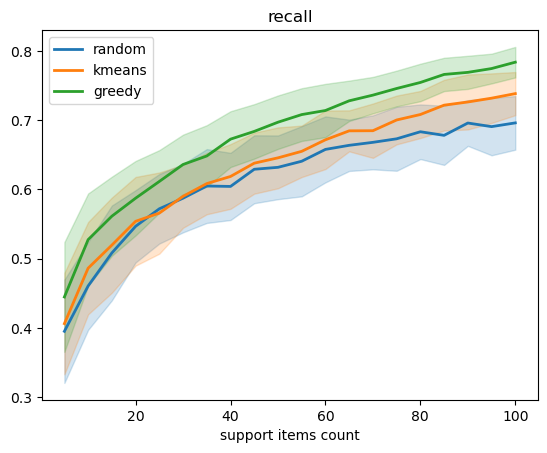

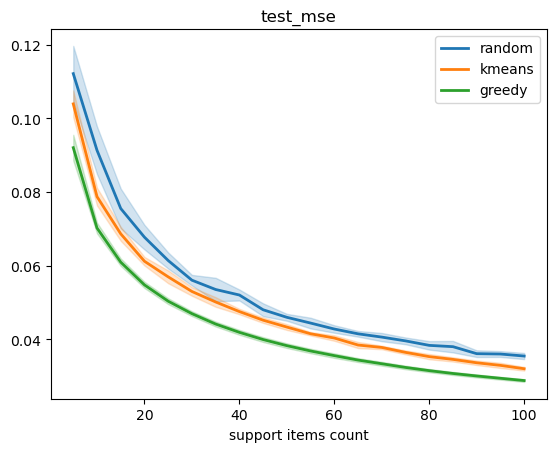

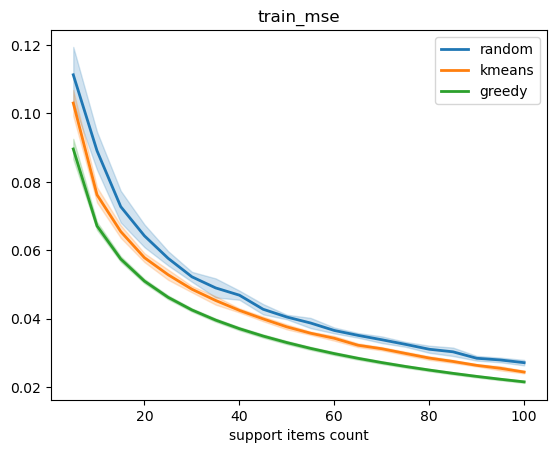

In [27]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for metric in ["recall", "test_mse", "train_mse"]:
    plt.title(metric)
    plt.xlabel("support items count")
    for method, color in zip(methods, colors):
        avg_values = np.array(stats[method][metric]).mean(axis=0)
        stds = np.array(stats[method][metric]).std(axis=0, ddof=1)
        plt.plot(
            item_cnt_range, avg_values, label=method, color=color,
            linewidth=2
        )
        plt.fill_between(item_cnt_range, avg_values - stds, avg_values + stds, color=color, alpha=0.2)
#         for run_values in stats[method][metric]:
#             plt.plot(item_cnt_range, run_values, color=color, linewidth=0.3)
    plt.legend()
    plt.show()


In [29]:
index = item_cnt_range.index(test_item_cnt)
for m in methods:
    recalls = np.array(stats[m]['recall'])[:, index]
    std = recalls.std(ddof=1) / np.sqrt(n_runs)
    print(f"{m:<10} {recalls.mean():<7.3} +- {std:.3f}")

random     0.696   +- 0.012
kmeans     0.738   +- 0.010
greedy     0.784   +- 0.007


In [40]:
for m1, m2 in combinations(methods, 2):
    m1_recalls = np.array(stats[m1]['recall'])[:, index]
    m2_recalls = np.array(stats[m2]['recall'])[:, index]
    ttest_pval = ttest_rel(m1_recalls, m2_recalls).pvalue
    mw_pval = mannwhitneyu(m1_recalls, m2_recalls).pvalue
    print(f"{m1} vs {m2}".ljust(20), f"ttest: {ttest_pval:<10.5f} mann-whitney: {mw_pval:<10.5f}")

random vs kmeans     ttest: 0.00012    mann-whitney: 0.01902   
random vs greedy     ttest: 0.00000    mann-whitney: 0.00024   
kmeans vs greedy     ttest: 0.00005    mann-whitney: 0.00406   
